# 基线模型评估分析

基于 `baseline_da_result.csv` / `baseline_rt_result.csv` / `baseline_metrics.csv`，
对 LightGBM 基线模型与 Naive（lag24h）基线进行系统性误差分析。

**分析框架：**
1. 整体性能概览
2. 预测 vs 实际时序对比
3. 残差分析（分布、自相关、系统性偏差）
4. 按小时/峰谷时段误差剖析
5. 按日期误差剖析 — 高误差日归因
6. SHAP 特征重要性分析
7. 迭代方向建议

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import seaborn as sns
import lightgbm as lgb
import shap
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style("whitegrid")

_CN_FONT_PATHS = [
    "/System/Library/Fonts/Hiragino Sans GB.ttc",
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
]
for _p in _CN_FONT_PATHS:
    if os.path.exists(_p):
        fm.fontManager.addfont(_p)
        _cn_name = fm.FontProperties(fname=_p).get_name()
        matplotlib.rcParams["font.family"] = "sans-serif"
        matplotlib.rcParams["font.sans-serif"] = [_cn_name]
        print(f"使用中文字体: {_cn_name} ({_p})")
        break
else:
    print("WARNING: 未找到中文字体文件")

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (14, 5)

OUTPUT_DIR = "../output"

da_res = pd.read_csv(f"{OUTPUT_DIR}/baseline_da_result.csv", parse_dates=["ts"], index_col="ts")
rt_res = pd.read_csv(f"{OUTPUT_DIR}/baseline_rt_result.csv", parse_dates=["ts"], index_col="ts")
metrics = pd.read_csv(f"{OUTPUT_DIR}/baseline_metrics.csv")

da_feat = pd.read_csv(f"{OUTPUT_DIR}/feature_da.csv", parse_dates=["ts"], index_col="ts")
rt_feat = pd.read_csv(f"{OUTPUT_DIR}/feature_rt.csv", parse_dates=["ts"], index_col="ts")

TARGET_DA = "target_da_clearing_price"
TARGET_RT = "target_rt_clearing_price"

TRAIN_END = "2026-02-08 23:00:00"
TEST_START = "2026-02-09 00:00:00"

PEAK_HOURS = set(range(8, 12)) | set(range(17, 21))
VALLEY_HOURS = set(range(0, 8)) | {23}
FLAT_HOURS = set(range(12, 17)) | set(range(21, 23))

def period_label(h):
    if h in PEAK_HOURS: return "峰"
    if h in VALLEY_HOURS: return "谷"
    return "平"

da_res["residual_lgb"] = da_res["actual"] - da_res["pred_lgb"]
da_res["residual_naive"] = da_res["actual"] - da_res["pred_naive"]
rt_res["residual_lgb"] = rt_res["actual"] - rt_res["pred_lgb"]
rt_res["residual_naive"] = rt_res["actual"] - rt_res["pred_naive"]

da_res["hour"] = da_res.index.hour
da_res["date"] = da_res.index.date
da_res["period"] = da_res["hour"].map(period_label)
rt_res["hour"] = rt_res.index.hour
rt_res["date"] = rt_res.index.date
rt_res["period"] = rt_res["hour"].map(period_label)

print(f"DA 测试集: {len(da_res)} 行, {da_res.index.min()} ~ {da_res.index.max()}")
print(f"RT 测试集: {len(rt_res)} 行, {rt_res.index.min()} ~ {rt_res.index.max()}")

使用中文字体: Hiragino Sans GB (/System/Library/Fonts/Hiragino Sans GB.ttc)
DA 测试集: 720 行, 2026-02-09 00:00:00 ~ 2026-03-10 23:00:00
RT 测试集: 720 行, 2026-02-09 00:00:00 ~ 2026-03-10 23:00:00


## 1. 整体性能概览

,MAE,RMSE,MAPE(%),count
label,,,,
DA - LGB,17.5363,36.2523,4.80,720
DA - NAIVE,23.7448,47.3116,6.37,720
RT - LGB,29.5003,57.3693,124.80,720
RT - NAIVE,41.1438,76.2362,115.68,720


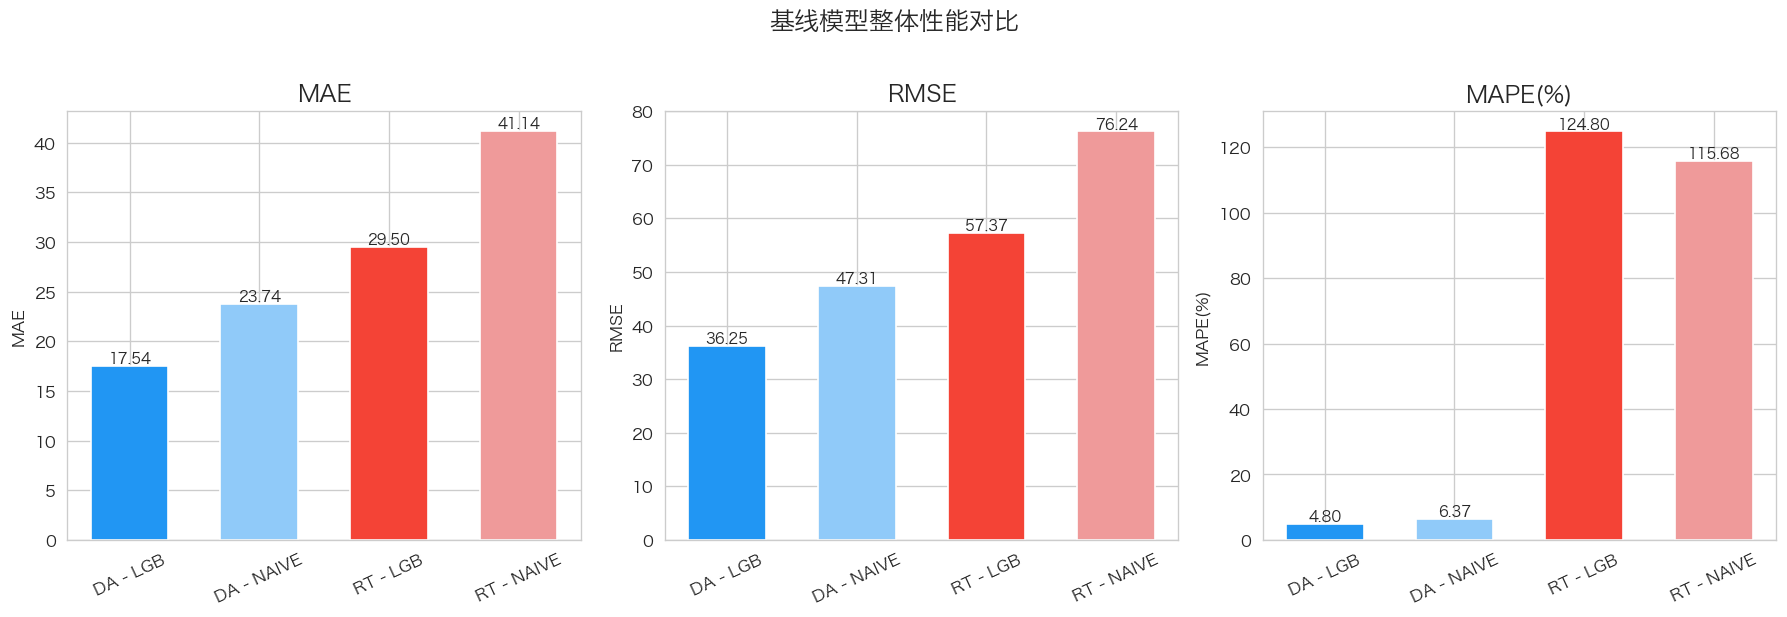

In [2]:
overall = metrics[metrics["group_type"] == "overall"].copy()
overall["label"] = overall["model"].str.upper() + " - " + overall["method"].str.upper()
display(overall[["label", "MAE", "RMSE", "MAPE(%)", "count"]].set_index("label"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(["MAE", "RMSE", "MAPE(%)"]):
    ax = axes[i]
    colors = ["#2196F3", "#90CAF9", "#F44336", "#EF9A9A"]
    bars = ax.bar(overall["label"], overall[metric], color=colors, edgecolor="white", width=0.6)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("基线模型整体性能对比", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_overall_comparison.png", bbox_inches="tight")
plt.show()

### 1.1 LightGBM 相比 Naive 的提升幅度

In [3]:
for model_name in ["da", "rt"]:
    lgb_row = overall[(overall["model"] == model_name) & (overall["method"] == "lgb")].iloc[0]
    naive_row = overall[(overall["model"] == model_name) & (overall["method"] == "naive")].iloc[0]
    print(f"\n{'='*50}")
    print(f"{model_name.upper()} 模型 — LightGBM vs Naive 提升:")
    for m in ["MAE", "RMSE", "MAPE(%)"]:
        improve = (naive_row[m] - lgb_row[m]) / naive_row[m] * 100
        print(f"  {m}: {naive_row[m]:.2f} → {lgb_row[m]:.2f} (↓{improve:.1f}%)")


DA 模型 — LightGBM vs Naive 提升:
  MAE: 23.74 → 17.54 (↓26.1%)
  RMSE: 47.31 → 36.25 (↓23.4%)
  MAPE(%): 6.37 → 4.80 (↓24.6%)

RT 模型 — LightGBM vs Naive 提升:
  MAE: 41.14 → 29.50 (↓28.3%)
  RMSE: 76.24 → 57.37 (↓24.7%)
  MAPE(%): 115.68 → 124.80 (↓-7.9%)


## 2. 预测 vs 实际：时序对比

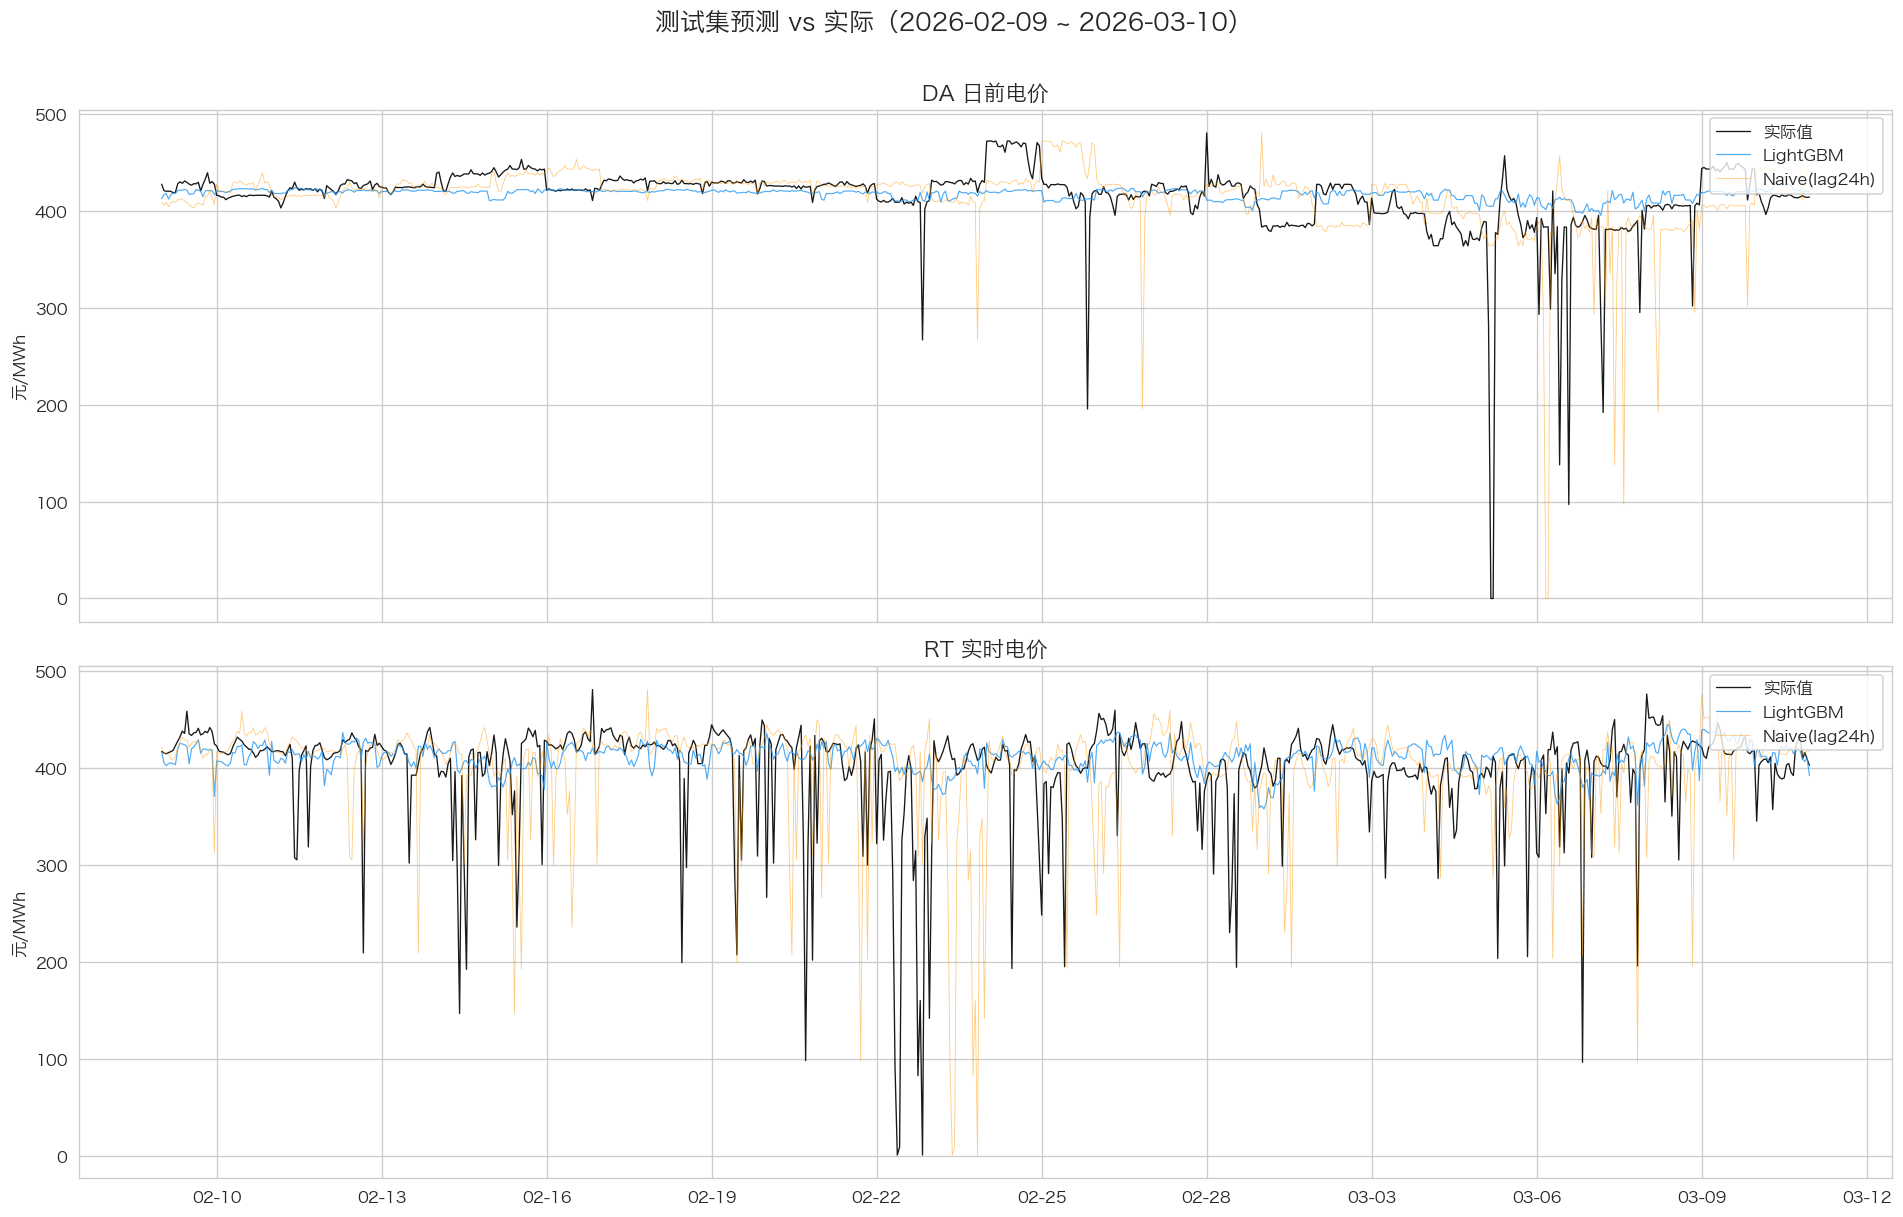

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, res, title in zip(axes, [da_res, rt_res], ["DA 日前电价", "RT 实时电价"]):
    ax.plot(res.index, res["actual"], color="black", linewidth=0.8, label="实际值", alpha=0.9)
    ax.plot(res.index, res["pred_lgb"], color="#2196F3", linewidth=0.7, label="LightGBM", alpha=0.8)
    ax.plot(res.index, res["pred_naive"], color="#FF9800", linewidth=0.5, label="Naive(lag24h)", alpha=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("元/MWh")
    ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

fig.suptitle("测试集预测 vs 实际（2026-02-09 ~ 2026-03-10）", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_pred_vs_actual.png", bbox_inches="tight")
plt.show()

### 2.1 预测 vs 实际散点图

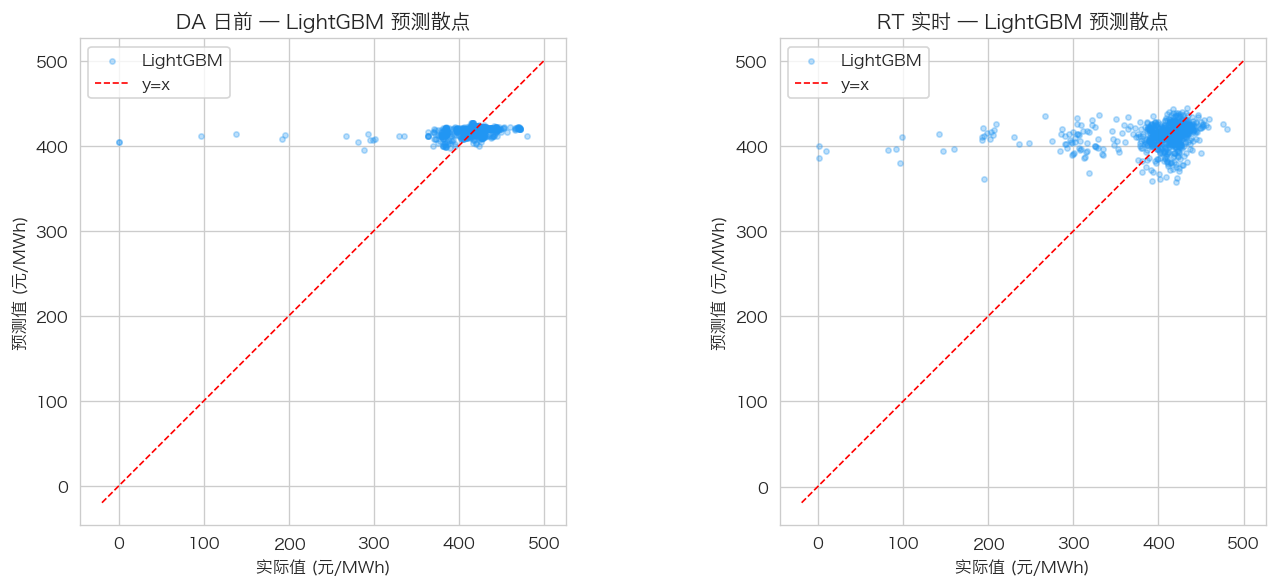

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, title in zip(axes, [da_res, rt_res], ["DA 日前", "RT 实时"]):
    ax.scatter(res["actual"], res["pred_lgb"], alpha=0.3, s=10, color="#2196F3", label="LightGBM")
    lims = [min(res["actual"].min(), res["pred_lgb"].min()) - 20,
            max(res["actual"].max(), res["pred_lgb"].max()) + 20]
    ax.plot(lims, lims, "--", color="red", linewidth=1, label="y=x")
    ax.set_xlabel("实际值 (元/MWh)")
    ax.set_ylabel("预测值 (元/MWh)")
    ax.set_title(f"{title} — LightGBM 预测散点", fontsize=12, fontweight="bold")
    ax.legend()
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_scatter.png", bbox_inches="tight")
plt.show()

### 2.2 典型单日预测放大

自动选取 MAE 中位数附近的"典型日"，直观展示 24 小时逐点预测效果。

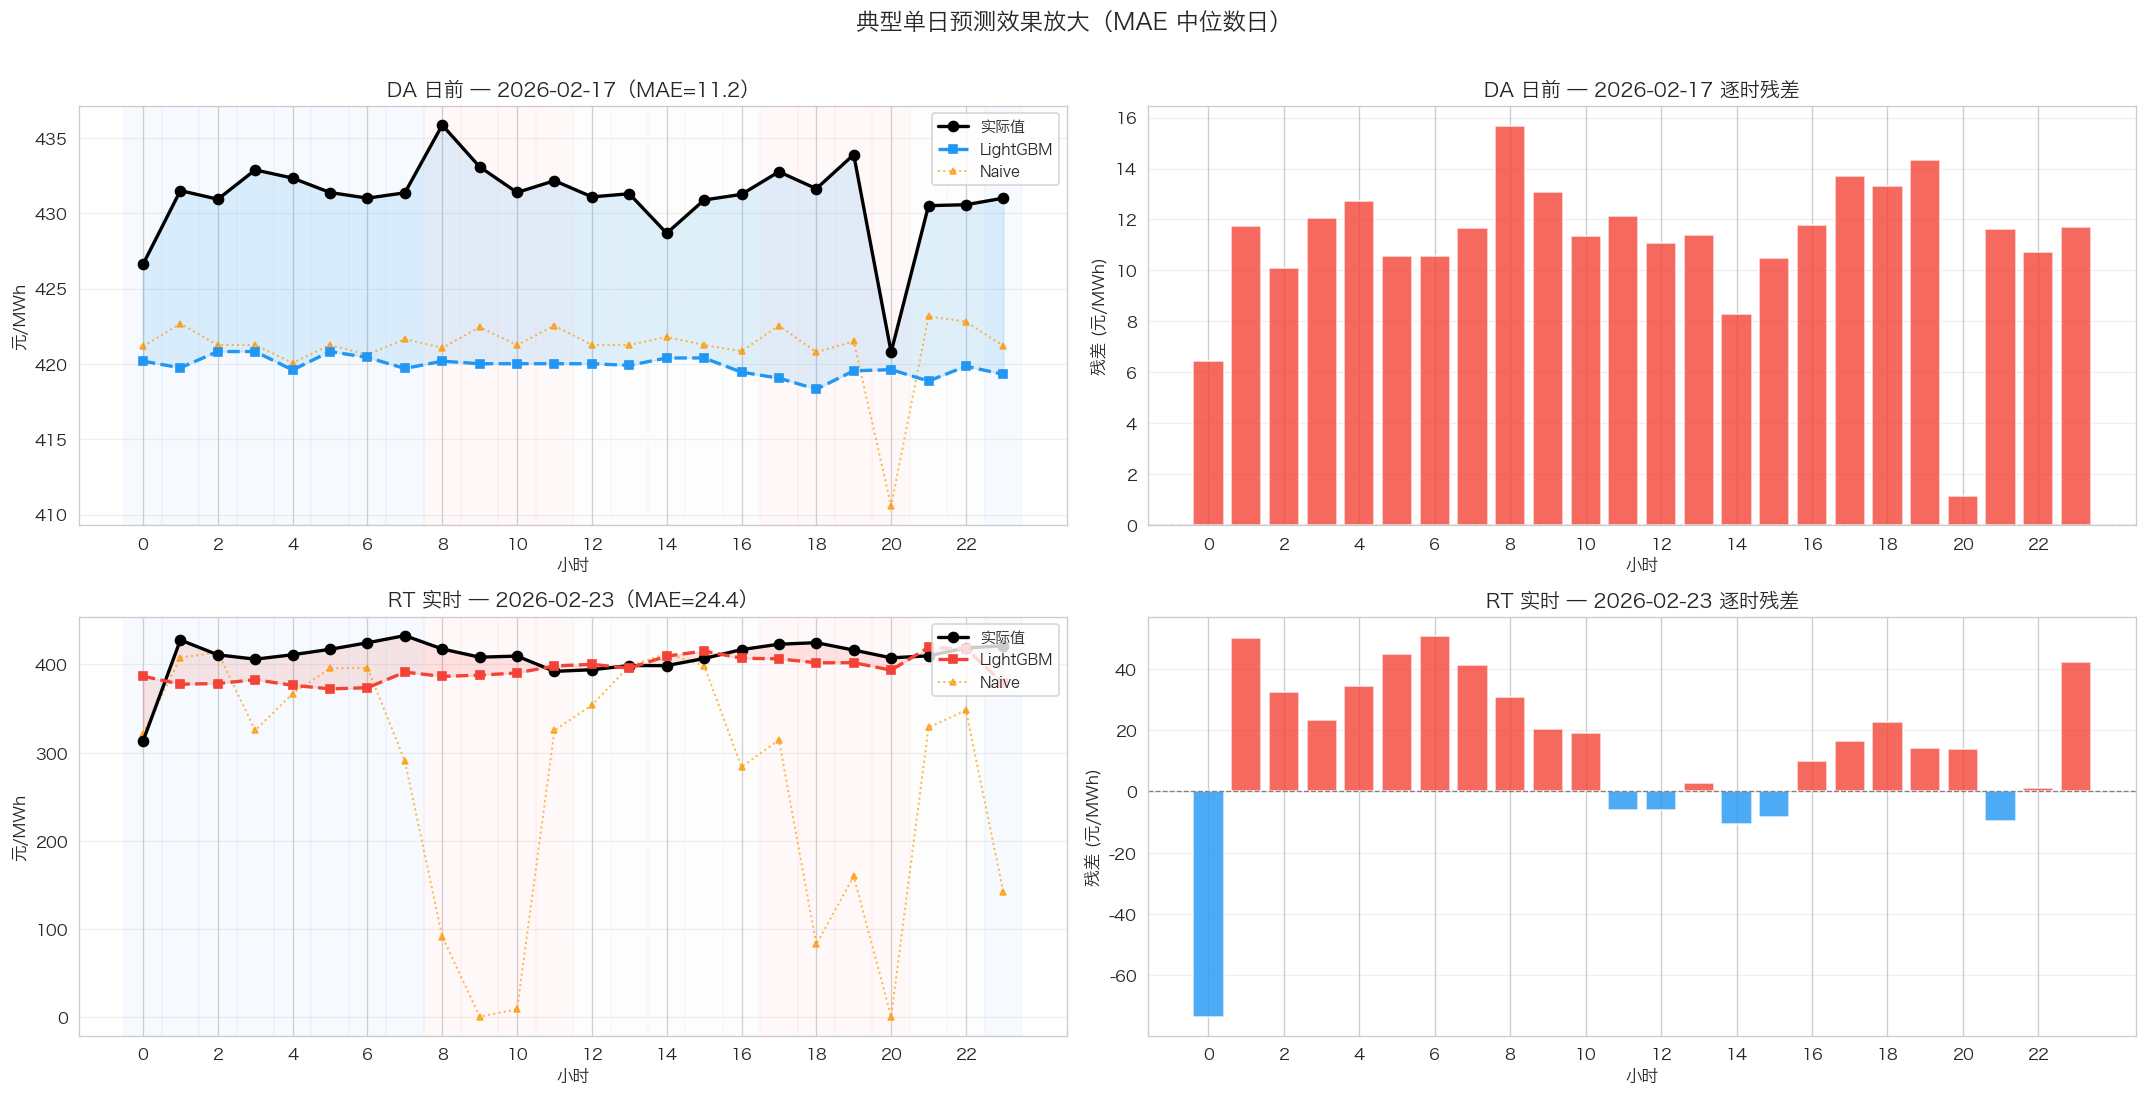

  DA 选取日期: 2026-02-17
  RT 选取日期: 2026-02-23


In [6]:
date_mae = metrics[(metrics["group_type"] == "date") & (metrics["method"] == "lgb")].copy()
date_mae["group_value"] = pd.to_datetime(date_mae["group_value"])

pick = {}
for model_name in ["da", "rt"]:
    sub = date_mae[date_mae["model"] == model_name].sort_values("MAE")
    pick[model_name] = sub.iloc[len(sub) // 2]["group_value"].date()

fig, axes = plt.subplots(2, 2, figsize=(18, 9))

for row, (res, model_name, color_lgb) in enumerate(
    [(da_res, "da", "#2196F3"), (rt_res, "rt", "#F44336")]
):
    d = pick[model_name]
    day = res[res["date"] == d].copy()
    mae_val = np.abs(day["residual_lgb"]).mean()
    title_prefix = "DA 日前" if model_name == "da" else "RT 实时"

    ax_left = axes[row, 0]
    ax_left.plot(day["hour"], day["actual"], "o-", color="black", linewidth=2, markersize=6, label="实际值", zorder=3)
    ax_left.plot(day["hour"], day["pred_lgb"], "s--", color=color_lgb, linewidth=2, markersize=5, label="LightGBM", zorder=3)
    ax_left.plot(day["hour"], day["pred_naive"], "^:", color="#FF9800", linewidth=1.2, markersize=4, label="Naive", alpha=0.7)
    ax_left.fill_between(day["hour"], day["actual"], day["pred_lgb"], alpha=0.15, color=color_lgb)
    for h in range(24):
        bg = "#FFCDD2" if h in PEAK_HOURS else ("#BBDEFB" if h in VALLEY_HOURS else "#E8F5E9")
        ax_left.axvspan(h - 0.5, h + 0.5, alpha=0.12, color=bg)
    ax_left.set_xlabel("小时")
    ax_left.set_ylabel("元/MWh")
    ax_left.set_title(f"{title_prefix} — {d}（MAE={mae_val:.1f}）", fontsize=12, fontweight="bold")
    ax_left.set_xticks(range(0, 24, 2))
    ax_left.legend(fontsize=9, loc="upper right")
    ax_left.grid(axis="y", alpha=0.3)

    ax_right = axes[row, 1]
    bars = ax_right.bar(day["hour"], day["residual_lgb"], color=np.where(day["residual_lgb"] > 0, "#F44336", "#2196F3"), alpha=0.8, edgecolor="white")
    ax_right.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax_right.set_xlabel("小时")
    ax_right.set_ylabel("残差 (元/MWh)")
    ax_right.set_title(f"{title_prefix} — {d} 逐时残差", fontsize=12, fontweight="bold")
    ax_right.set_xticks(range(0, 24, 2))
    ax_right.grid(axis="y", alpha=0.3)

fig.suptitle("典型单日预测效果放大（MAE 中位数日）", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_zoom_single_day.png", bbox_inches="tight")
plt.show()

for model_name in ["da", "rt"]:
    print(f"  {model_name.upper()} 选取日期: {pick[model_name]}")

### 2.3 典型单周预测放大

选取测试集中间的一整周（168h），展示周内日间模式和预测跟踪能力。

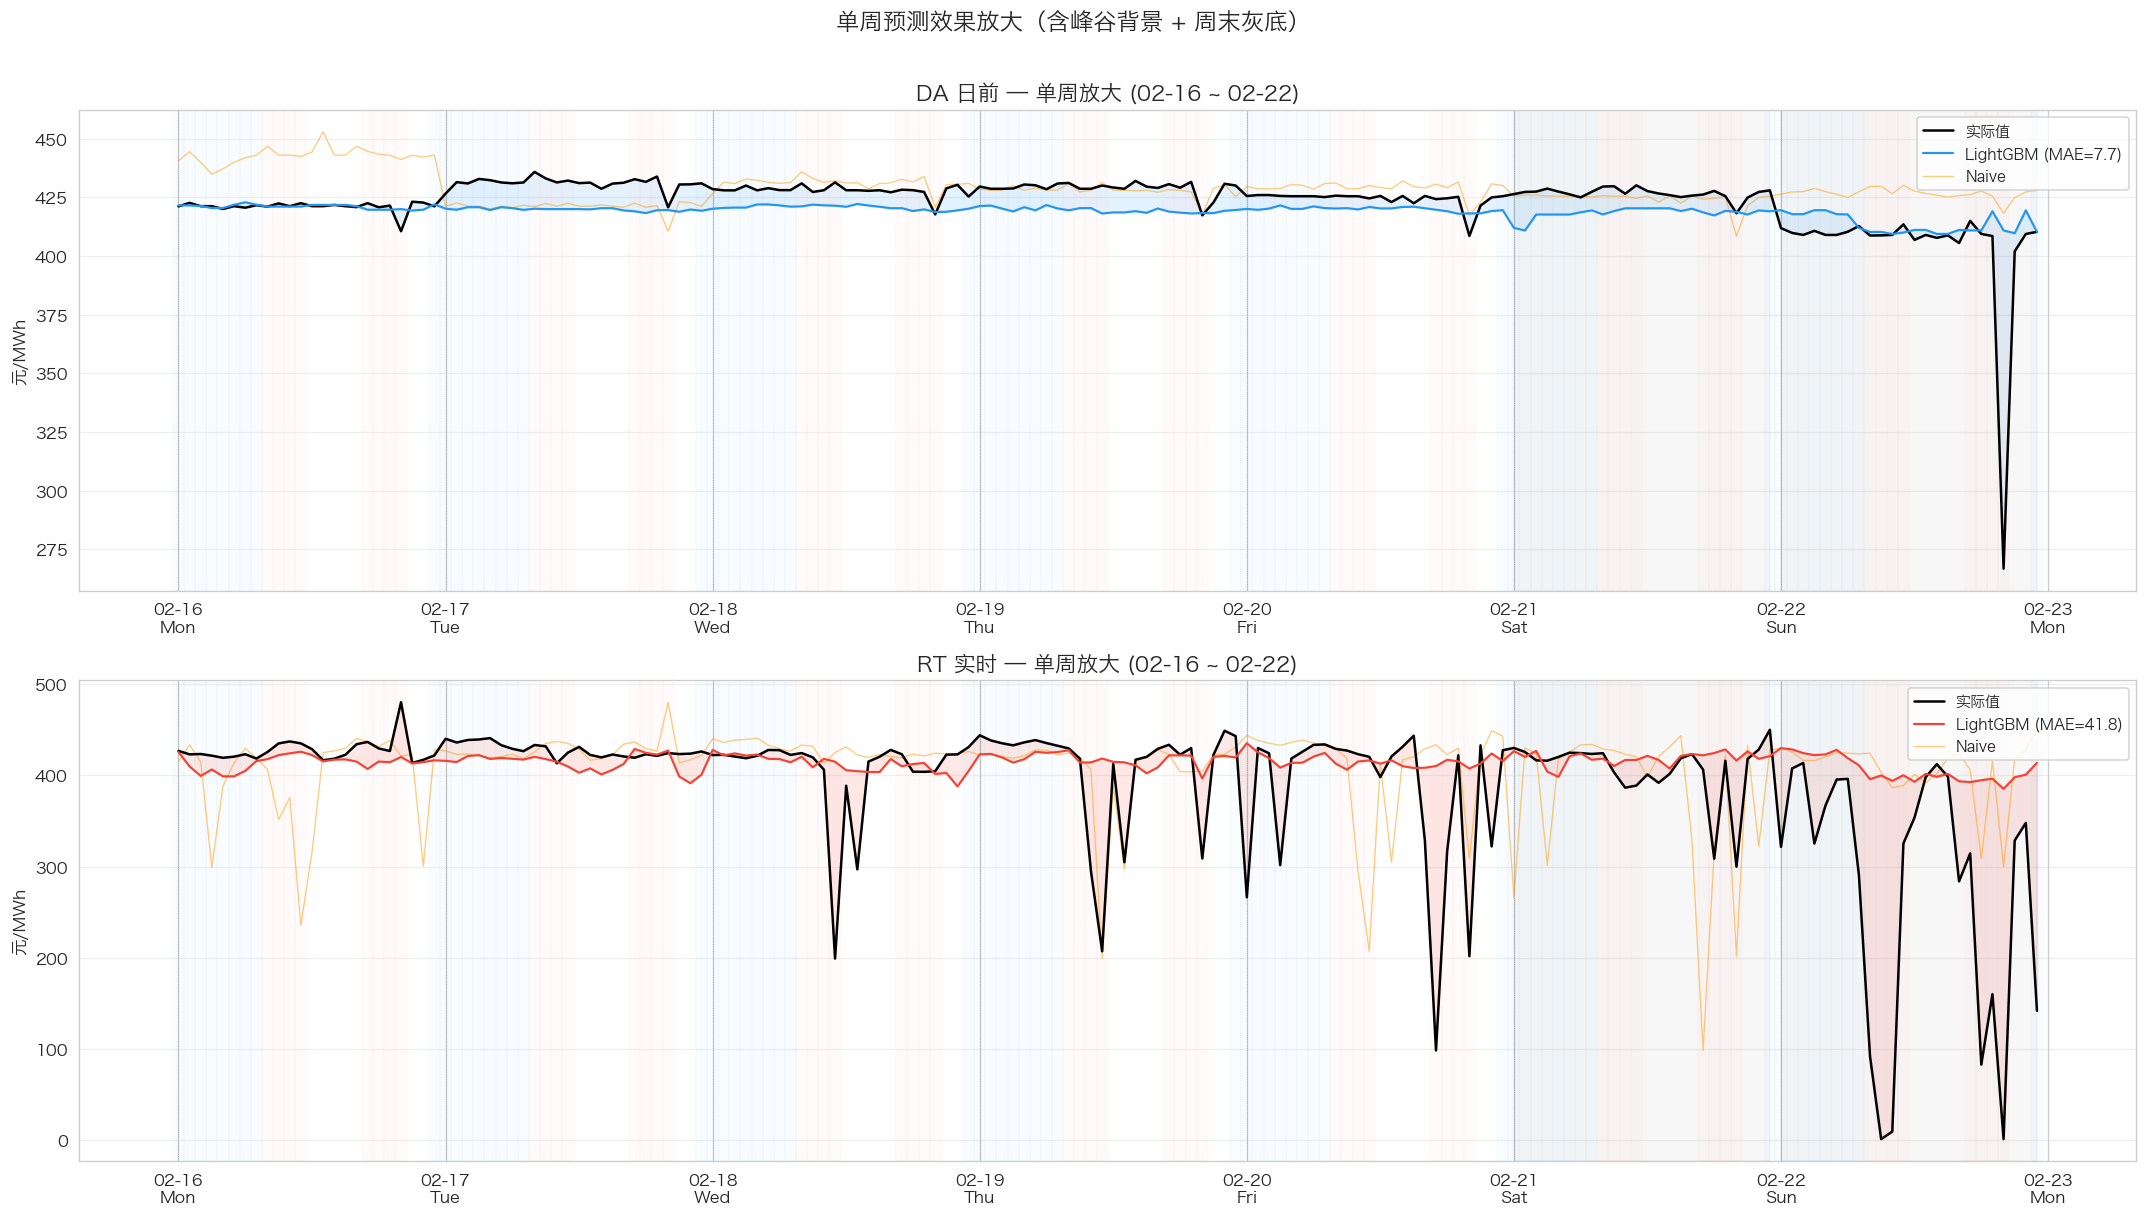

  DA 周内统计: MAE=7.68, 最大偏差=144.2, 均值偏差=4.34
  RT 周内统计: MAE=41.76, 最大偏差=399.0, 均值偏差=-25.09


In [7]:
week_start = pd.Timestamp("2026-02-16")
week_end = pd.Timestamp("2026-02-22 23:00:00")

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for ax, res, title, color_lgb in zip(
    axes, [da_res, rt_res], ["DA 日前", "RT 实时"], ["#2196F3", "#F44336"]
):
    week = res.loc[week_start:week_end]
    mae_w = np.abs(week["residual_lgb"]).mean()

    ax.plot(week.index, week["actual"], color="black", linewidth=1.5, label="实际值", zorder=3)
    ax.plot(week.index, week["pred_lgb"], color=color_lgb, linewidth=1.3, label=f"LightGBM (MAE={mae_w:.1f})", zorder=3)
    ax.plot(week.index, week["pred_naive"], color="#FF9800", linewidth=0.8, label="Naive", alpha=0.5)
    ax.fill_between(week.index, week["actual"], week["pred_lgb"], alpha=0.12, color=color_lgb)

    for d in pd.date_range(week_start, week_end, freq="D"):
        for h in range(24):
            t = d + pd.Timedelta(hours=h)
            if t > week_end:
                break
            bg = "#FFCDD2" if h in PEAK_HOURS else ("#BBDEFB" if h in VALLEY_HOURS else None)
            if bg:
                ax.axvspan(t - pd.Timedelta(minutes=30), t + pd.Timedelta(minutes=30), alpha=0.08, color=bg)

    for d in pd.date_range(week_start, week_end, freq="D"):
        if d.dayofweek >= 5:
            ax.axvspan(d, d + pd.Timedelta(hours=23), alpha=0.06, color="gray")

    for d in pd.date_range(week_start, week_end, freq="D"):
        ax.axvline(d, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)

    ax.set_ylabel("元/MWh")
    ax.set_title(f"{title} — 单周放大 ({week_start.strftime('%m-%d')} ~ {week_end.strftime('%m-%d')})",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%a"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("单周预测效果放大（含峰谷背景 + 周末灰底）", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_zoom_single_week.png", bbox_inches="tight")
plt.show()

for name, res in [("DA", da_res), ("RT", rt_res)]:
    week = res.loc[week_start:week_end]
    print(f"  {name} 周内统计: MAE={np.abs(week['residual_lgb']).mean():.2f}, "
          f"最大偏差={week['residual_lgb'].abs().max():.1f}, "
          f"均值偏差={week['residual_lgb'].mean():.2f}")

## 3. 残差分析

### 3.1 残差分布

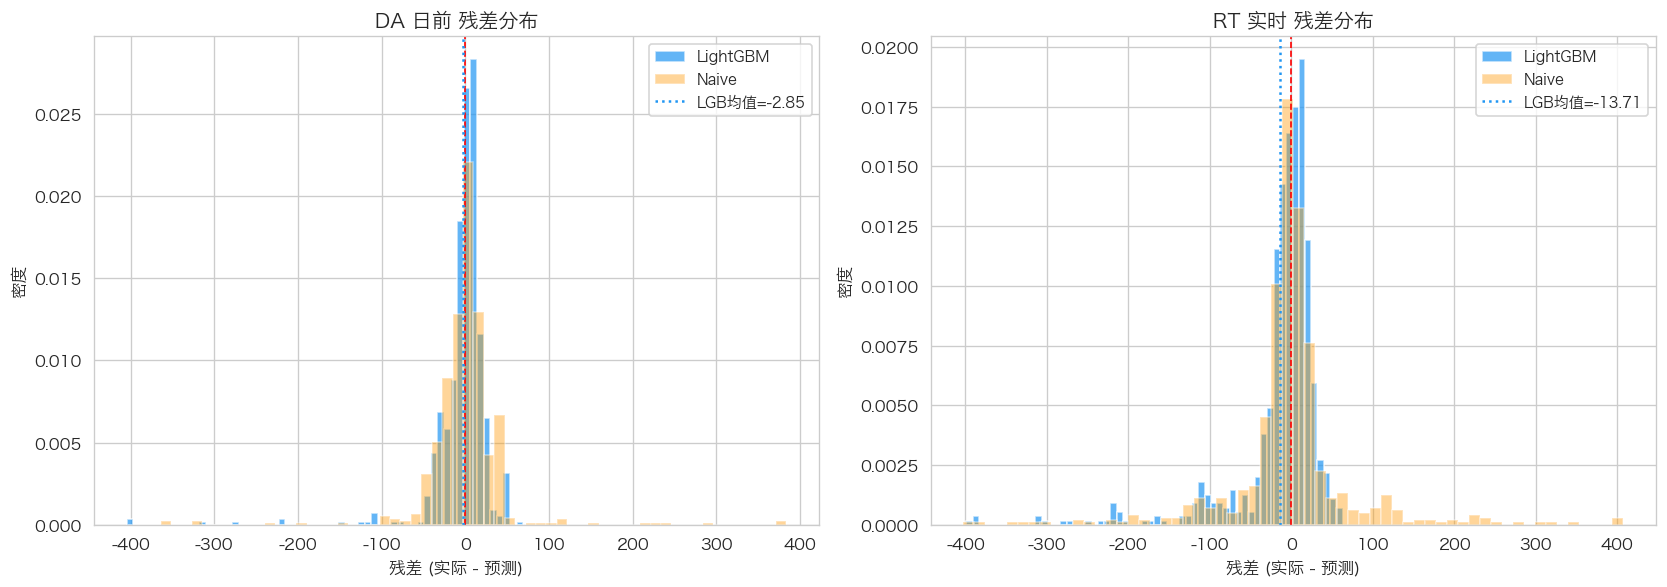

残差统计量:
  DA LGB: mean=-2.85, std=36.17, skew=-6.17, kurtosis=56.81, median=2.99
  RT LGB: mean=-13.71, std=55.75, skew=-3.36, kurtosis=14.57, median=0.07


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in zip(axes, [da_res, rt_res], ["DA 日前", "RT 实时"]):
    ax.hist(res["residual_lgb"], bins=60, alpha=0.7, color="#2196F3", label="LightGBM", density=True)
    ax.hist(res["residual_naive"], bins=60, alpha=0.4, color="#FF9800", label="Naive", density=True)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.axvline(res["residual_lgb"].mean(), color="#2196F3", linestyle=":", linewidth=1.5,
              label=f"LGB均值={res['residual_lgb'].mean():.2f}")
    ax.set_xlabel("残差 (实际 - 预测)")
    ax.set_ylabel("密度")
    ax.set_title(f"{title} 残差分布", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_residual_distribution.png", bbox_inches="tight")
plt.show()

print("残差统计量:")
for name, res in [("DA", da_res), ("RT", rt_res)]:
    r = res["residual_lgb"]
    print(f"  {name} LGB: mean={r.mean():.2f}, std={r.std():.2f}, "
          f"skew={r.skew():.2f}, kurtosis={r.kurtosis():.2f}, "
          f"median={r.median():.2f}")

### 3.2 残差时序图 — 检查系统性偏差

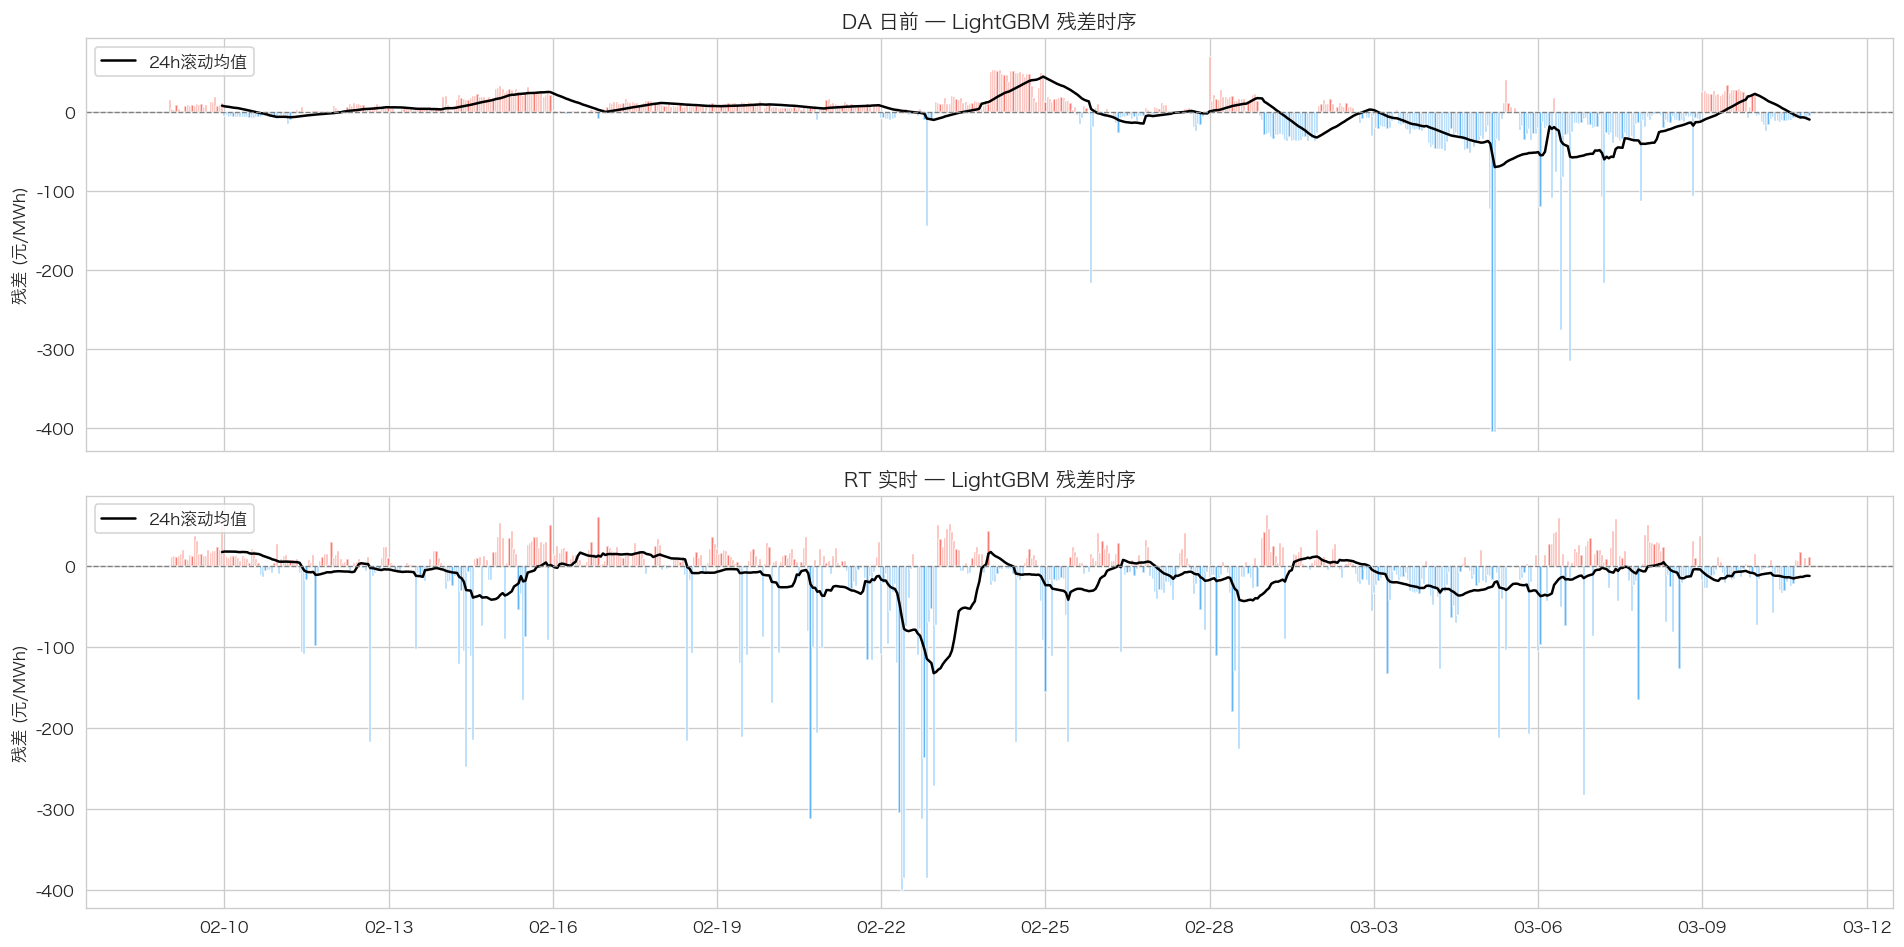

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, res, title in zip(axes, [da_res, rt_res], ["DA 日前", "RT 实时"]):
    ax.bar(res.index, res["residual_lgb"], width=0.04, color=np.where(res["residual_lgb"] > 0, "#F44336", "#2196F3"), alpha=0.7)
    roll_mean = res["residual_lgb"].rolling(24).mean()
    ax.plot(res.index, roll_mean, color="black", linewidth=1.5, label="24h滚动均值")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylabel("残差 (元/MWh)")
    ax.set_title(f"{title} — LightGBM 残差时序", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_residual_timeseries.png", bbox_inches="tight")
plt.show()

### 3.3 残差自相关图 — 是否存在未捕获的时序模式

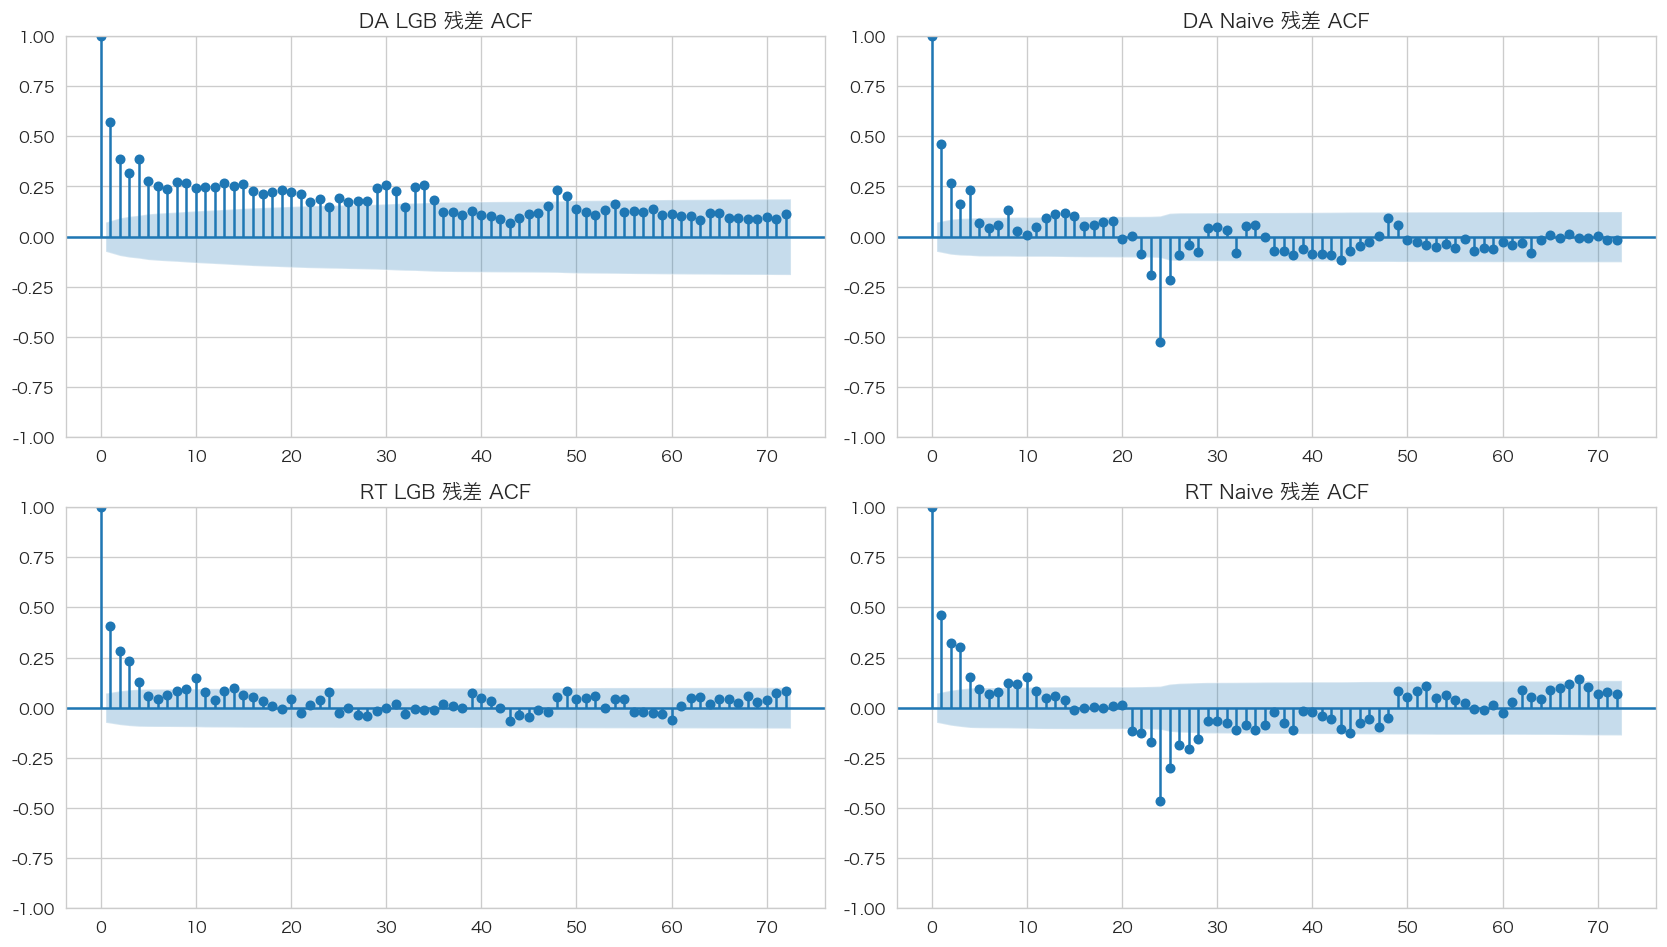

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (res, title) in enumerate([(da_res, "DA"), (rt_res, "RT")]):
    plot_acf(res["residual_lgb"].dropna(), lags=72, ax=axes[i, 0], title=f"{title} LGB 残差 ACF")
    plot_acf(res["residual_naive"].dropna(), lags=72, ax=axes[i, 1], title=f"{title} Naive 残差 ACF")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_residual_acf.png", bbox_inches="tight")
plt.show()

## 4. 按小时 / 峰谷时段误差剖析

### 4.1 按小时 MAE 曲线

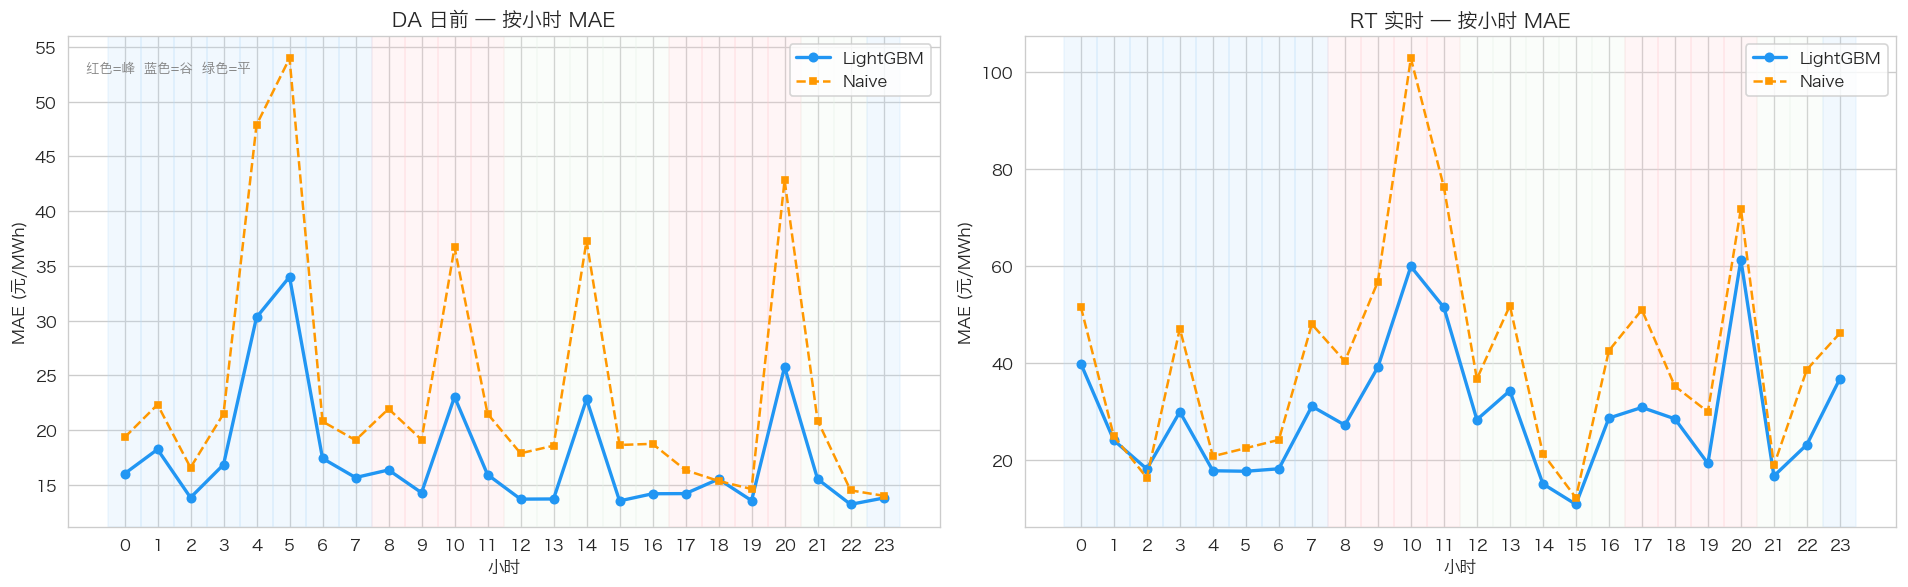

In [11]:
hourly = metrics[metrics["group_type"] == "hour"].copy()
hourly["group_value"] = hourly["group_value"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_name, title in zip(axes, ["da", "rt"], ["DA 日前", "RT 实时"]):
    subset = hourly[hourly["model"] == model_name]
    lgb_h = subset[subset["method"] == "lgb"].sort_values("group_value")
    naive_h = subset[subset["method"] == "naive"].sort_values("group_value")

    ax.plot(lgb_h["group_value"], lgb_h["MAE"], "o-", color="#2196F3", linewidth=2, markersize=5, label="LightGBM")
    ax.plot(naive_h["group_value"], naive_h["MAE"], "s--", color="#FF9800", linewidth=1.5, markersize=4, label="Naive")

    for h in range(24):
        color = "#FFCDD2" if h in PEAK_HOURS else ("#BBDEFB" if h in VALLEY_HOURS else "#E8F5E9")
        ax.axvspan(h - 0.5, h + 0.5, alpha=0.2, color=color)

    ax.set_xlabel("小时")
    ax.set_ylabel("MAE (元/MWh)")
    ax.set_title(f"{title} — 按小时 MAE", fontsize=12, fontweight="bold")
    ax.set_xticks(range(24))
    ax.legend()

axes[0].text(0.02, 0.95, "红色=峰  蓝色=谷  绿色=平", transform=axes[0].transAxes,
            fontsize=8, va="top", color="gray")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_hourly_mae.png", bbox_inches="tight")
plt.show()

### 4.2 按小时 RMSE 与 MAPE

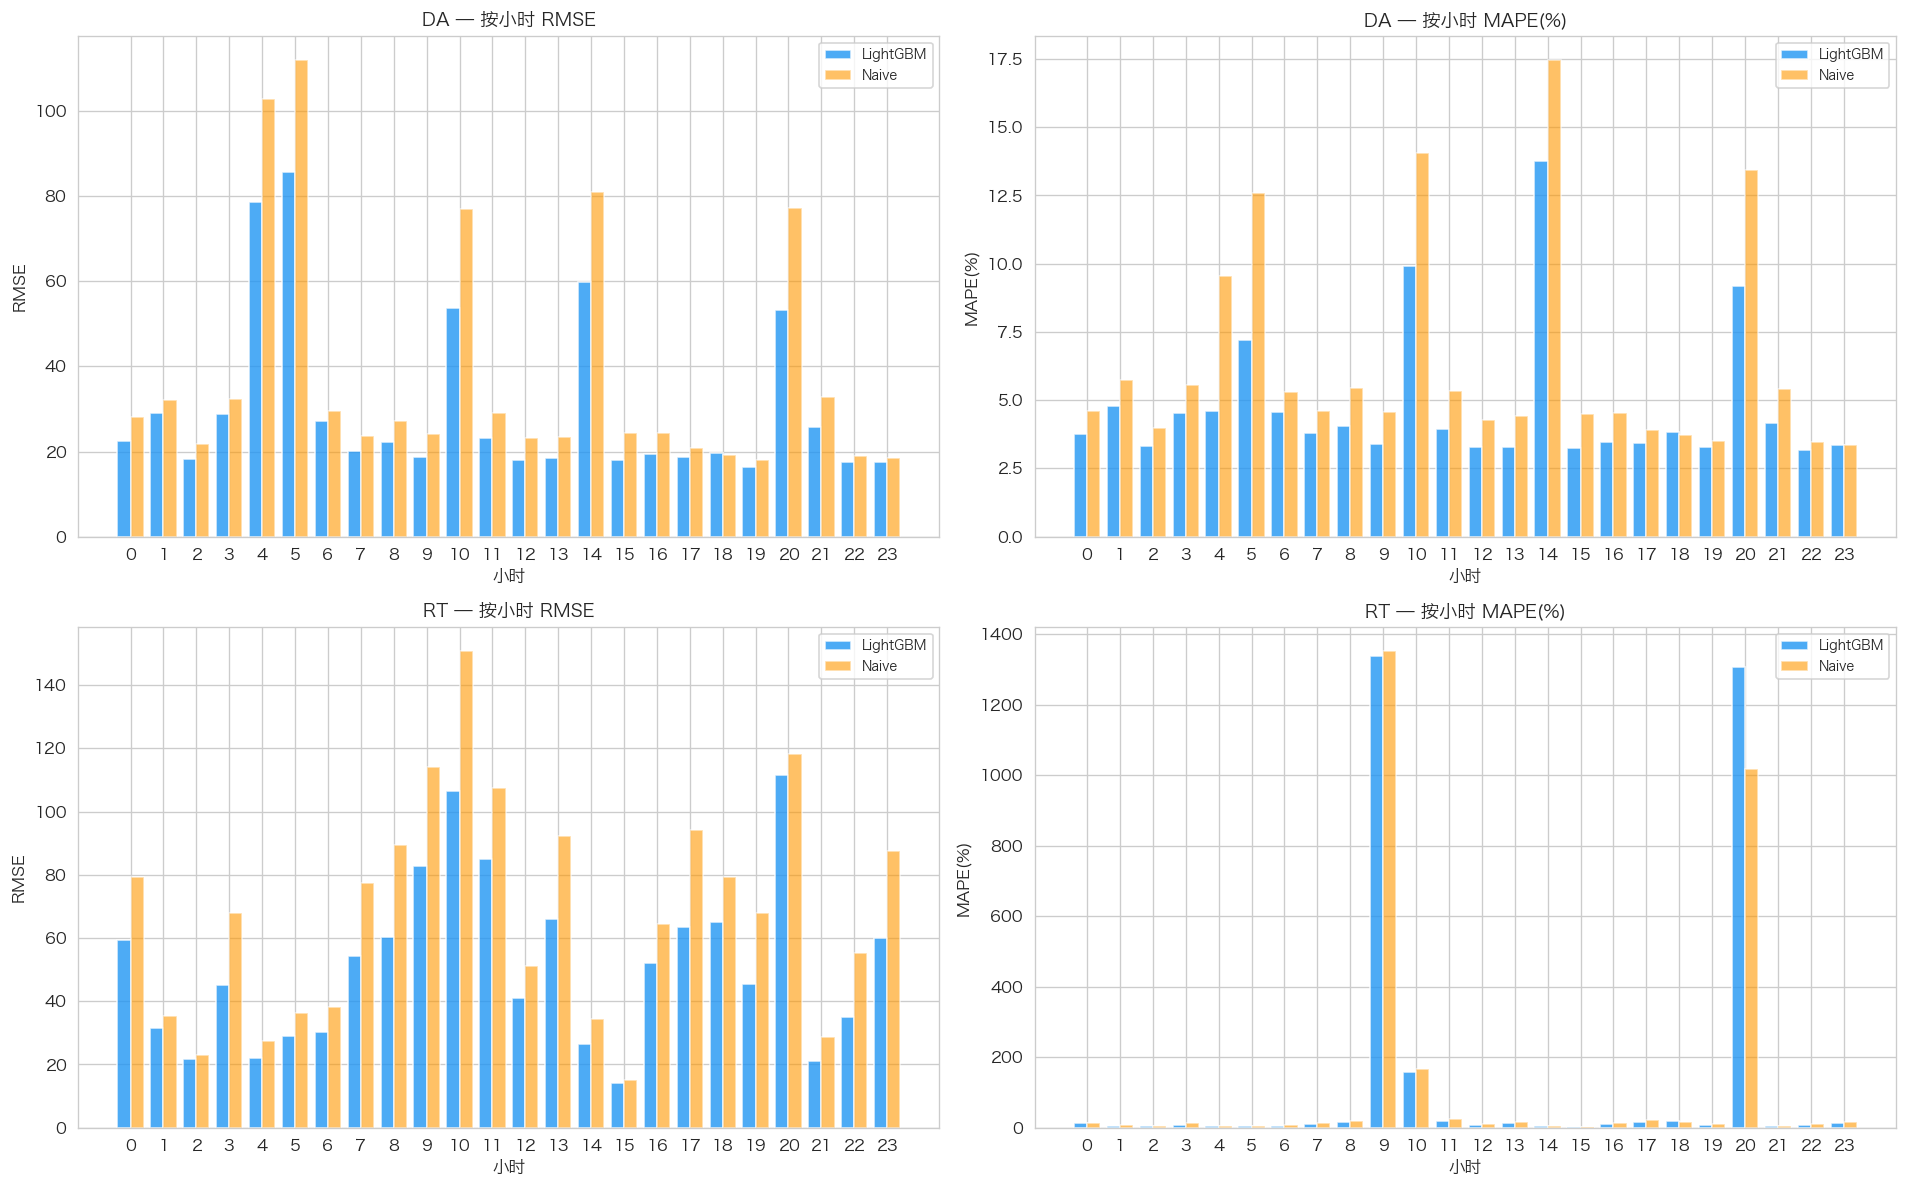

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, metric_name in enumerate(["RMSE", "MAPE(%)"]):
    for row_idx, (model_name, title) in enumerate([("da", "DA"), ("rt", "RT")]):
        ax = axes[row_idx, col_idx]
        subset = hourly[hourly["model"] == model_name]
        lgb_h = subset[subset["method"] == "lgb"].sort_values("group_value")
        naive_h = subset[subset["method"] == "naive"].sort_values("group_value")

        ax.bar(lgb_h["group_value"] - 0.2, lgb_h[metric_name], width=0.4,
               color="#2196F3", alpha=0.8, label="LightGBM")
        ax.bar(naive_h["group_value"] + 0.2, naive_h[metric_name], width=0.4,
               color="#FF9800", alpha=0.6, label="Naive")
        ax.set_xlabel("小时")
        ax.set_ylabel(metric_name)
        ax.set_title(f"{title} — 按小时 {metric_name}", fontsize=11, fontweight="bold")
        ax.set_xticks(range(24))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_hourly_rmse_mape.png", bbox_inches="tight")
plt.show()

### 4.3 峰谷时段对比

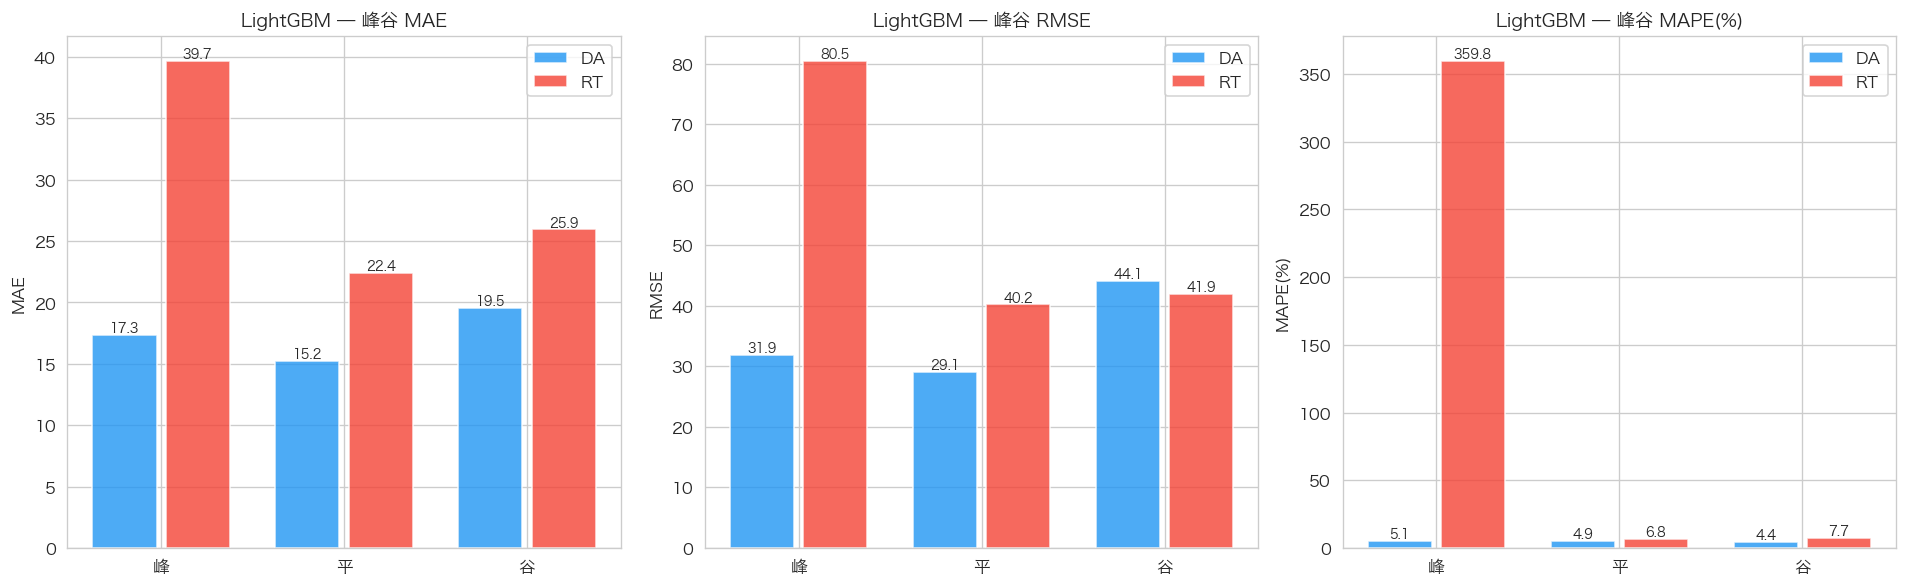

In [13]:
period_metrics = metrics[metrics["group_type"] == "period"].copy()
period_order = {"peak": "峰", "flat": "平", "valley": "谷"}
period_metrics["时段"] = period_metrics["group_value"].map(period_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_period = {"峰": "#F44336", "平": "#4CAF50", "谷": "#2196F3"}

for i, metric_name in enumerate(["MAE", "RMSE", "MAPE(%)"]):
    ax = axes[i]
    for model_name, offset in [("da", -0.2), ("rt", 0.2)]:
        sub = period_metrics[(period_metrics["model"] == model_name) & (period_metrics["method"] == "lgb")]
        x_vals = [0, 1, 2]
        x_labels = ["峰", "平", "谷"]
        vals = [sub[sub["时段"] == p][metric_name].values[0] if len(sub[sub["时段"] == p]) > 0 else 0 for p in x_labels]
        bars = ax.bar([x + offset for x in x_vals], vals, width=0.35,
                      label=model_name.upper(), alpha=0.8,
                      color="#2196F3" if model_name == "da" else "#F44336")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_labels)
    ax.set_title(f"LightGBM — 峰谷 {metric_name}", fontsize=11, fontweight="bold")
    ax.set_ylabel(metric_name)
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_period_comparison.png", bbox_inches="tight")
plt.show()

### 4.4 按峰谷时段的残差箱线图

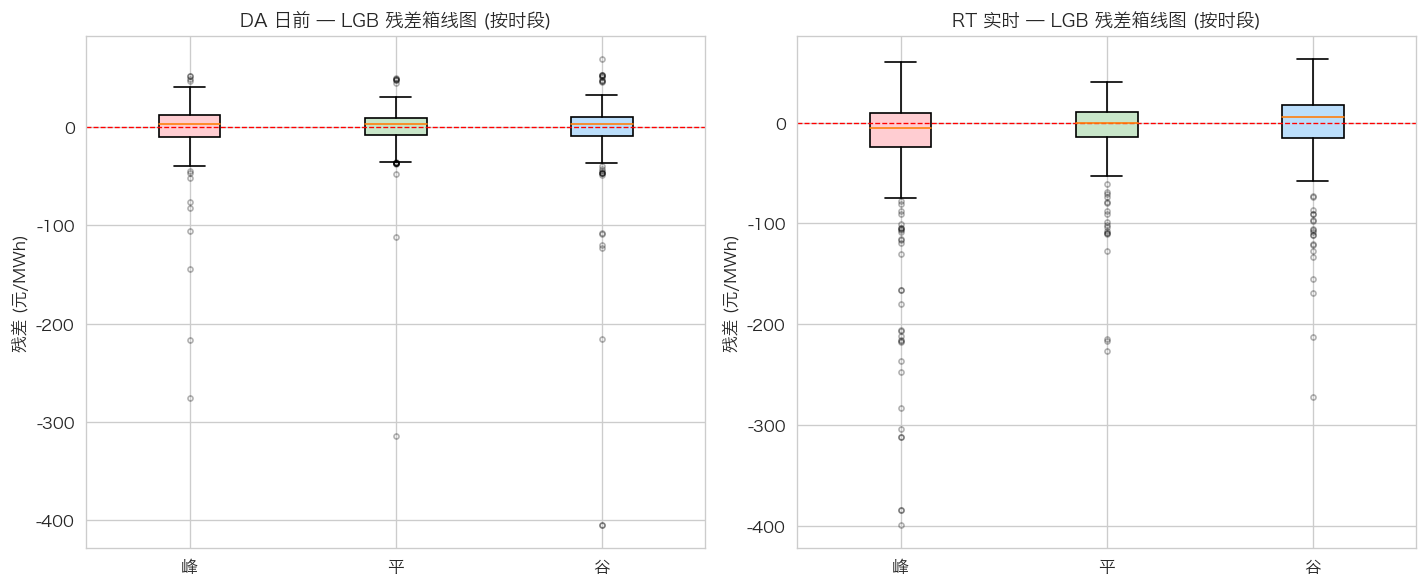

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
period_order_list = ["峰", "平", "谷"]

for ax, res, title in zip(axes, [da_res, rt_res], ["DA 日前", "RT 实时"]):
    data_for_box = [res[res["period"] == p]["residual_lgb"].values for p in period_order_list]
    bp = ax.boxplot(data_for_box, labels=period_order_list, patch_artist=True, showfliers=True,
                    flierprops=dict(marker="o", markersize=3, alpha=0.3))
    colors_box = ["#FFCDD2", "#C8E6C9", "#BBDEFB"]
    for patch, c in zip(bp["boxes"], colors_box):
        patch.set_facecolor(c)
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylabel("残差 (元/MWh)")
    ax.set_title(f"{title} — LGB 残差箱线图 (按时段)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_period_residual_box.png", bbox_inches="tight")
plt.show()

## 5. 按日期误差剖析 — 高误差日归因

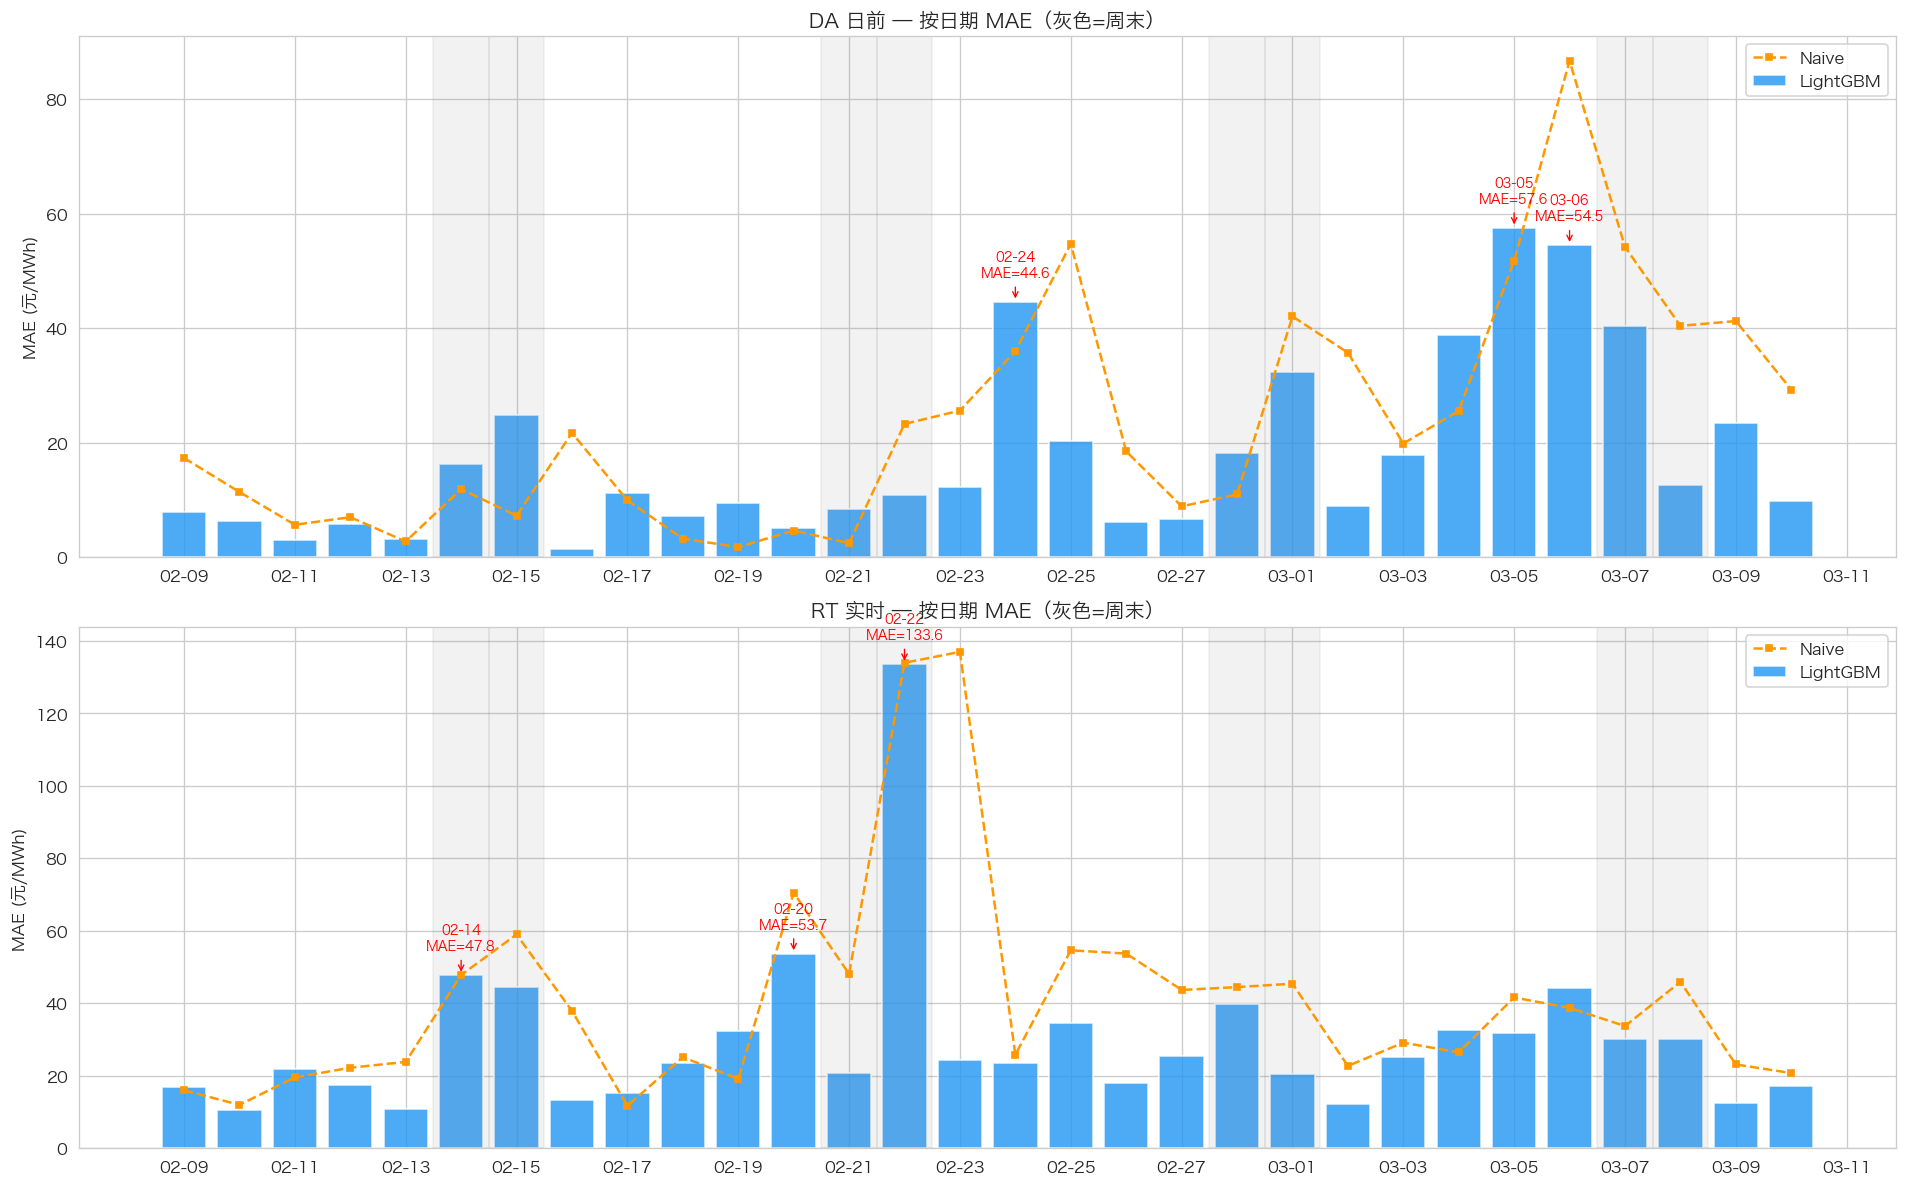

In [15]:
date_metrics = metrics[metrics["group_type"] == "date"].copy()
date_metrics["group_value"] = pd.to_datetime(date_metrics["group_value"])
date_metrics["day_of_week"] = date_metrics["group_value"].dt.dayofweek
date_metrics["is_weekend"] = date_metrics["day_of_week"] >= 5

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, model_name, title in zip(axes, ["da", "rt"], ["DA 日前", "RT 实时"]):
    lgb_d = date_metrics[(date_metrics["model"] == model_name) & (date_metrics["method"] == "lgb")].sort_values("group_value")
    naive_d = date_metrics[(date_metrics["model"] == model_name) & (date_metrics["method"] == "naive")].sort_values("group_value")

    ax.bar(lgb_d["group_value"], lgb_d["MAE"], width=0.8, color="#2196F3", alpha=0.8, label="LightGBM")
    ax.plot(naive_d["group_value"], naive_d["MAE"], "s--", color="#FF9800", markersize=4, label="Naive")

    weekend_dates = lgb_d[lgb_d["is_weekend"]]["group_value"]
    for d in weekend_dates:
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), alpha=0.1, color="gray")

    top3 = lgb_d.nlargest(3, "MAE")
    for _, row in top3.iterrows():
        ax.annotate(f"{row['group_value'].strftime('%m-%d')}\nMAE={row['MAE']:.1f}",
                    xy=(row["group_value"], row["MAE"]),
                    xytext=(0, 15), textcoords="offset points",
                    ha="center", fontsize=8, color="red",
                    arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

    ax.set_ylabel("MAE (元/MWh)")
    ax.set_title(f"{title} — 按日期 MAE（灰色=周末）", fontsize=12, fontweight="bold")
    ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_daily_mae.png", bbox_inches="tight")
plt.show()

### 5.1 高误差日详细分析

In [16]:
print("=" * 70)
print("DA 日前 — MAE Top-5 日期:")
print("=" * 70)
da_daily_lgb = date_metrics[(date_metrics["model"] == "da") & (date_metrics["method"] == "lgb")]
top5_da = da_daily_lgb.nlargest(5, "MAE")
for _, row in top5_da.iterrows():
    d = row["group_value"]
    day_data = da_res[da_res["date"] == d.date()]
    print(f"\n  {d.strftime('%Y-%m-%d')} ({'周末' if row['is_weekend'] else '工作日'}) "
          f"MAE={row['MAE']:.2f}  RMSE={row['RMSE']:.2f}  MAPE={row['MAPE(%)']:.2f}%")
    print(f"    实际价: [{day_data['actual'].min():.1f}, {day_data['actual'].max():.1f}]  "
          f"均值={day_data['actual'].mean():.1f}")
    print(f"    预测价: [{day_data['pred_lgb'].min():.1f}, {day_data['pred_lgb'].max():.1f}]  "
          f"均值={day_data['pred_lgb'].mean():.1f}")
    worst_hour = day_data.loc[day_data["residual_lgb"].abs().idxmax()]
    print(f"    最大偏差小时: {worst_hour.name.hour}时  "
          f"残差={worst_hour['residual_lgb']:.1f}")

print("\n" + "=" * 70)
print("RT 实时 — MAE Top-5 日期:")
print("=" * 70)
rt_daily_lgb = date_metrics[(date_metrics["model"] == "rt") & (date_metrics["method"] == "lgb")]
top5_rt = rt_daily_lgb.nlargest(5, "MAE")
for _, row in top5_rt.iterrows():
    d = row["group_value"]
    day_data = rt_res[rt_res["date"] == d.date()]
    print(f"\n  {d.strftime('%Y-%m-%d')} ({'周末' if row['is_weekend'] else '工作日'}) "
          f"MAE={row['MAE']:.2f}  RMSE={row['RMSE']:.2f}  MAPE={row['MAPE(%)']:.2f}%")
    print(f"    实际价: [{day_data['actual'].min():.1f}, {day_data['actual'].max():.1f}]  "
          f"均值={day_data['actual'].mean():.1f}")
    print(f"    预测价: [{day_data['pred_lgb'].min():.1f}, {day_data['pred_lgb'].max():.1f}]  "
          f"均值={day_data['pred_lgb'].mean():.1f}")
    worst_hour = day_data.loc[day_data["residual_lgb"].abs().idxmax()]
    print(f"    最大偏差小时: {worst_hour.name.hour}时  "
          f"残差={worst_hour['residual_lgb']:.1f}")

DA 日前 — MAE Top-5 日期:

  2026-03-05 (工作日) MAE=57.57  RMSE=121.72  MAPE=7.21%
    实际价: [0.0, 456.8]  均值=359.4
    预测价: [403.5, 420.5]  均值=410.8
    最大偏差小时: 4时  残差=-404.7

  2026-03-06 (工作日) MAE=54.50  RMSE=95.87  MAPE=30.61%
    实际价: [97.0, 420.4]  均值=353.6
    预测价: [397.4, 413.9]  均值=406.6
    最大偏差小时: 14时  残差=-314.4

  2026-02-24 (工作日) MAE=44.63  RMSE=45.84  MAPE=9.55%
    实际价: [433.0, 472.0]  均值=465.0
    预测价: [418.3, 422.4]  均值=420.4
    最大偏差小时: 1时  残差=53.0

  2026-03-07 (周末) MAE=40.44  RMSE=59.90  MAPE=13.67%
    实际价: [191.9, 400.3]  均值=367.7
    预测价: [395.2, 420.8]  均值=408.1
    最大偏差小时: 5时  残差=-215.9

  2026-03-04 (工作日) MAE=38.90  RMSE=39.78  MAPE=10.42%
    实际价: [363.6, 399.3]  均值=375.4
    预测价: [400.1, 422.3]  均值=414.3
    最大偏差小时: 18时  残差=-51.8

RT 实时 — MAE Top-5 日期:

  2026-02-22 (周末) MAE=133.62  RMSE=188.08  MAPE=3493.11%
    实际价: [1.0, 413.8]  均值=273.7
    预测价: [385.3, 430.0]  均值=406.2
    最大偏差小时: 9时  残差=-399.0

  2026-02-20 (工作日) MAE=53.73  RMSE=93.67  MAPE=27.34%
    实际价: [9

### 5.2 高误差日的日内曲线对比

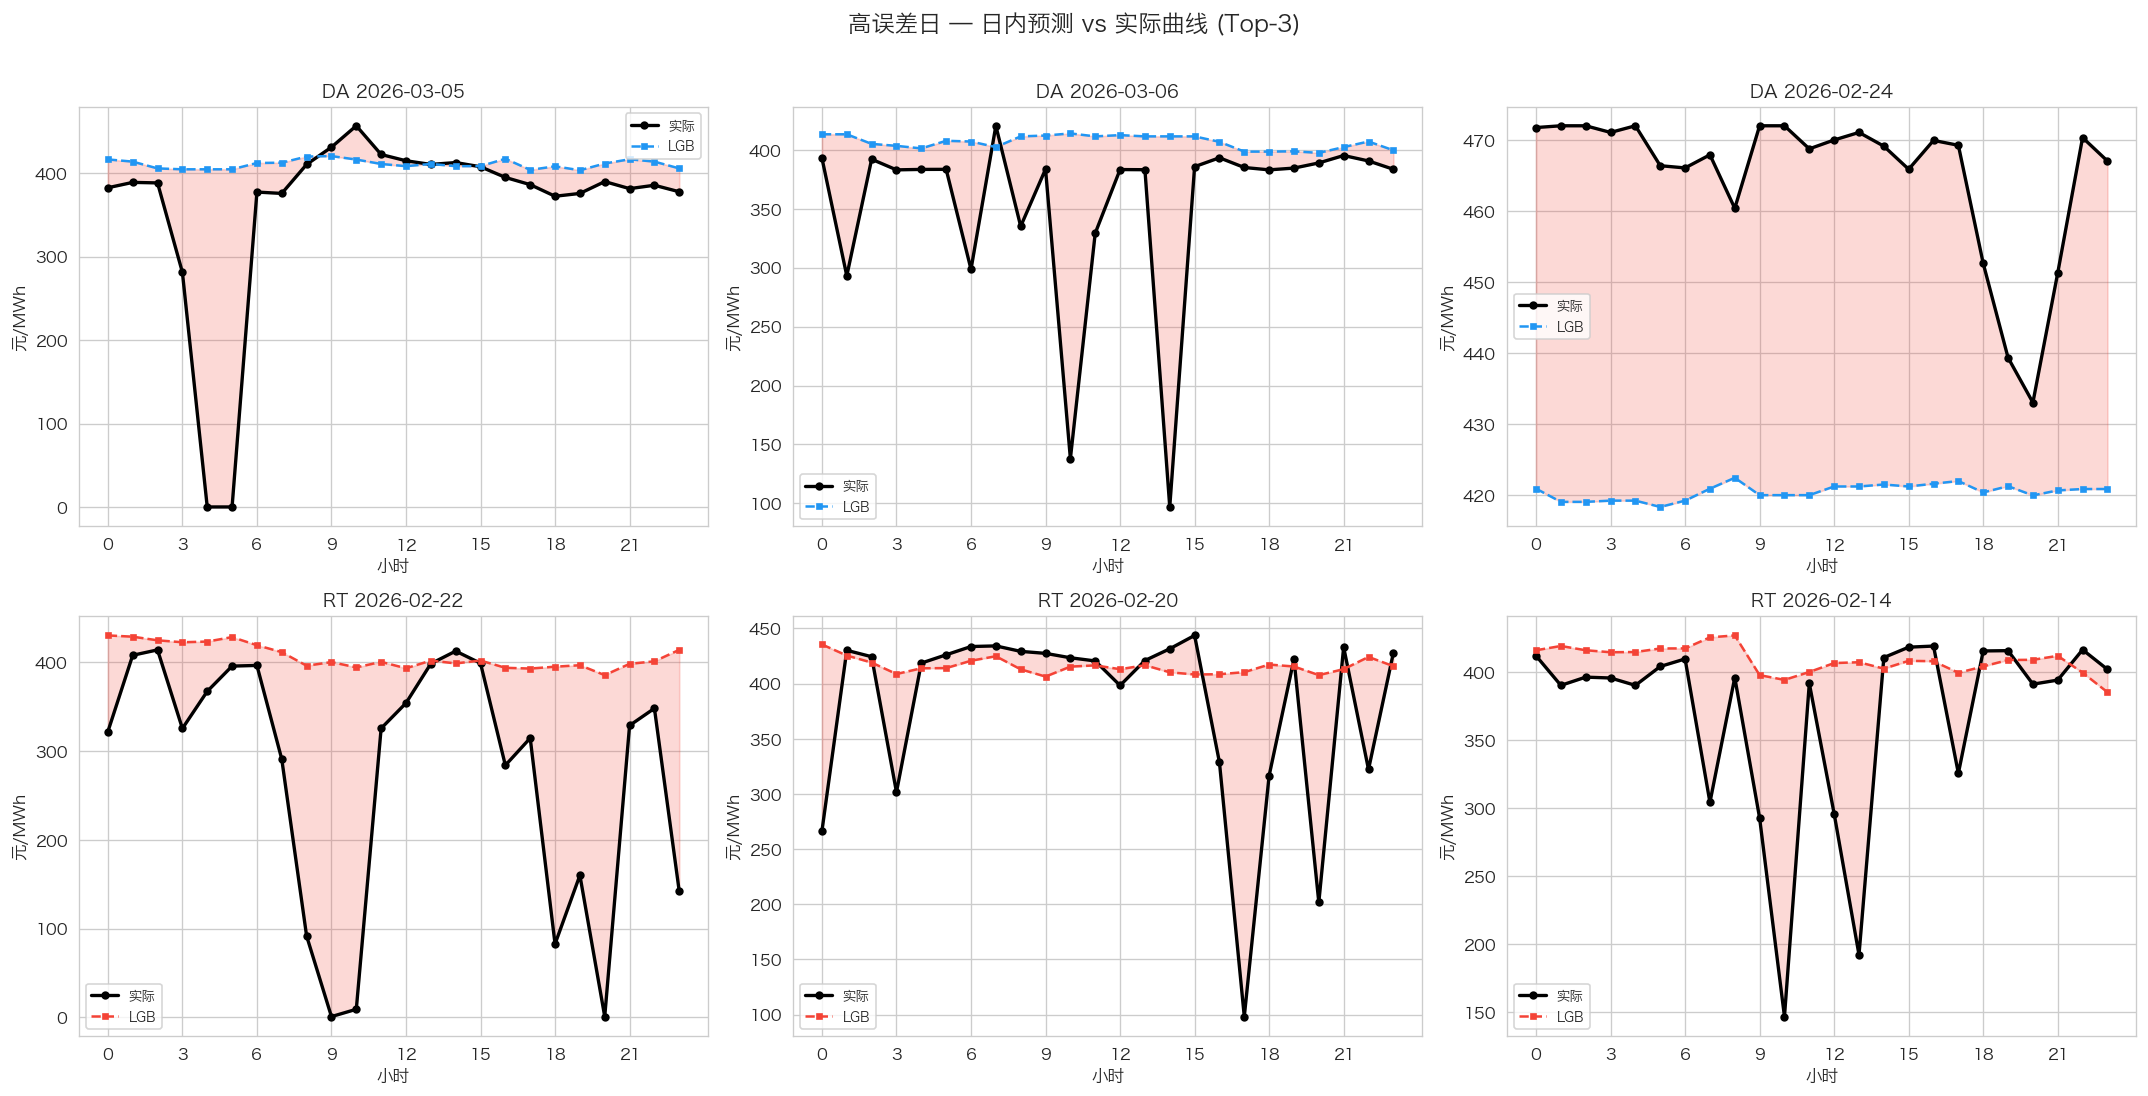

In [17]:
top3_da_dates = da_daily_lgb.nlargest(3, "MAE")["group_value"].dt.date.tolist()
top3_rt_dates = rt_daily_lgb.nlargest(3, "MAE")["group_value"].dt.date.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, d in enumerate(top3_da_dates):
    ax = axes[0, col]
    day = da_res[da_res["date"] == d]
    ax.plot(day["hour"], day["actual"], "o-", color="black", linewidth=2, markersize=4, label="实际")
    ax.plot(day["hour"], day["pred_lgb"], "s--", color="#2196F3", linewidth=1.5, markersize=3, label="LGB")
    ax.fill_between(day["hour"], day["actual"], day["pred_lgb"], alpha=0.2, color="#F44336")
    ax.set_title(f"DA {d}", fontsize=11, fontweight="bold")
    ax.set_xlabel("小时")
    ax.set_ylabel("元/MWh")
    ax.legend(fontsize=8)
    ax.set_xticks(range(0, 24, 3))

for col, d in enumerate(top3_rt_dates):
    ax = axes[1, col]
    day = rt_res[rt_res["date"] == d]
    ax.plot(day["hour"], day["actual"], "o-", color="black", linewidth=2, markersize=4, label="实际")
    ax.plot(day["hour"], day["pred_lgb"], "s--", color="#F44336", linewidth=1.5, markersize=3, label="LGB")
    ax.fill_between(day["hour"], day["actual"], day["pred_lgb"], alpha=0.2, color="#F44336")
    ax.set_title(f"RT {d}", fontsize=11, fontweight="bold")
    ax.set_xlabel("小时")
    ax.set_ylabel("元/MWh")
    ax.legend(fontsize=8)
    ax.set_xticks(range(0, 24, 3))

fig.suptitle("高误差日 — 日内预测 vs 实际曲线 (Top-3)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_worst_days_intraday.png", bbox_inches="tight")
plt.show()

## 6. SHAP 特征重要性分析

### 6.1 重新训练模型并计算 SHAP

In [18]:
LGB_PARAMS = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 8,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "seed": 42,
}

shap_results = {}

for name, feat_df, target in [("da", da_feat, TARGET_DA), ("rt", rt_feat, TARGET_RT)]:
    feature_cols = [c for c in feat_df.columns if c != target]
    train = feat_df.loc[:TRAIN_END]
    test = feat_df.loc[TEST_START:]

    X_train, y_train = train[feature_cols], train[target]
    X_test, y_test = test[feature_cols], test[target]

    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_test, label=y_test, reference=dtrain)
    model = lgb.train(
        LGB_PARAMS, dtrain, num_boost_round=1000,
        valid_sets=[dtrain, dval], valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_results[name] = {
        "model": model,
        "explainer": explainer,
        "shap_values": shap_values,
        "X_test": X_test,
        "feature_cols": feature_cols,
    }
    print(f"{name.upper()}: best_iteration={model.best_iteration}, "
          f"test samples={len(X_test)}, features={len(feature_cols)}")

DA: best_iteration=7, test samples=720, features=39


RT: best_iteration=50, test samples=720, features=41


### 6.2 SHAP 全局特征重要性 (Top-15)

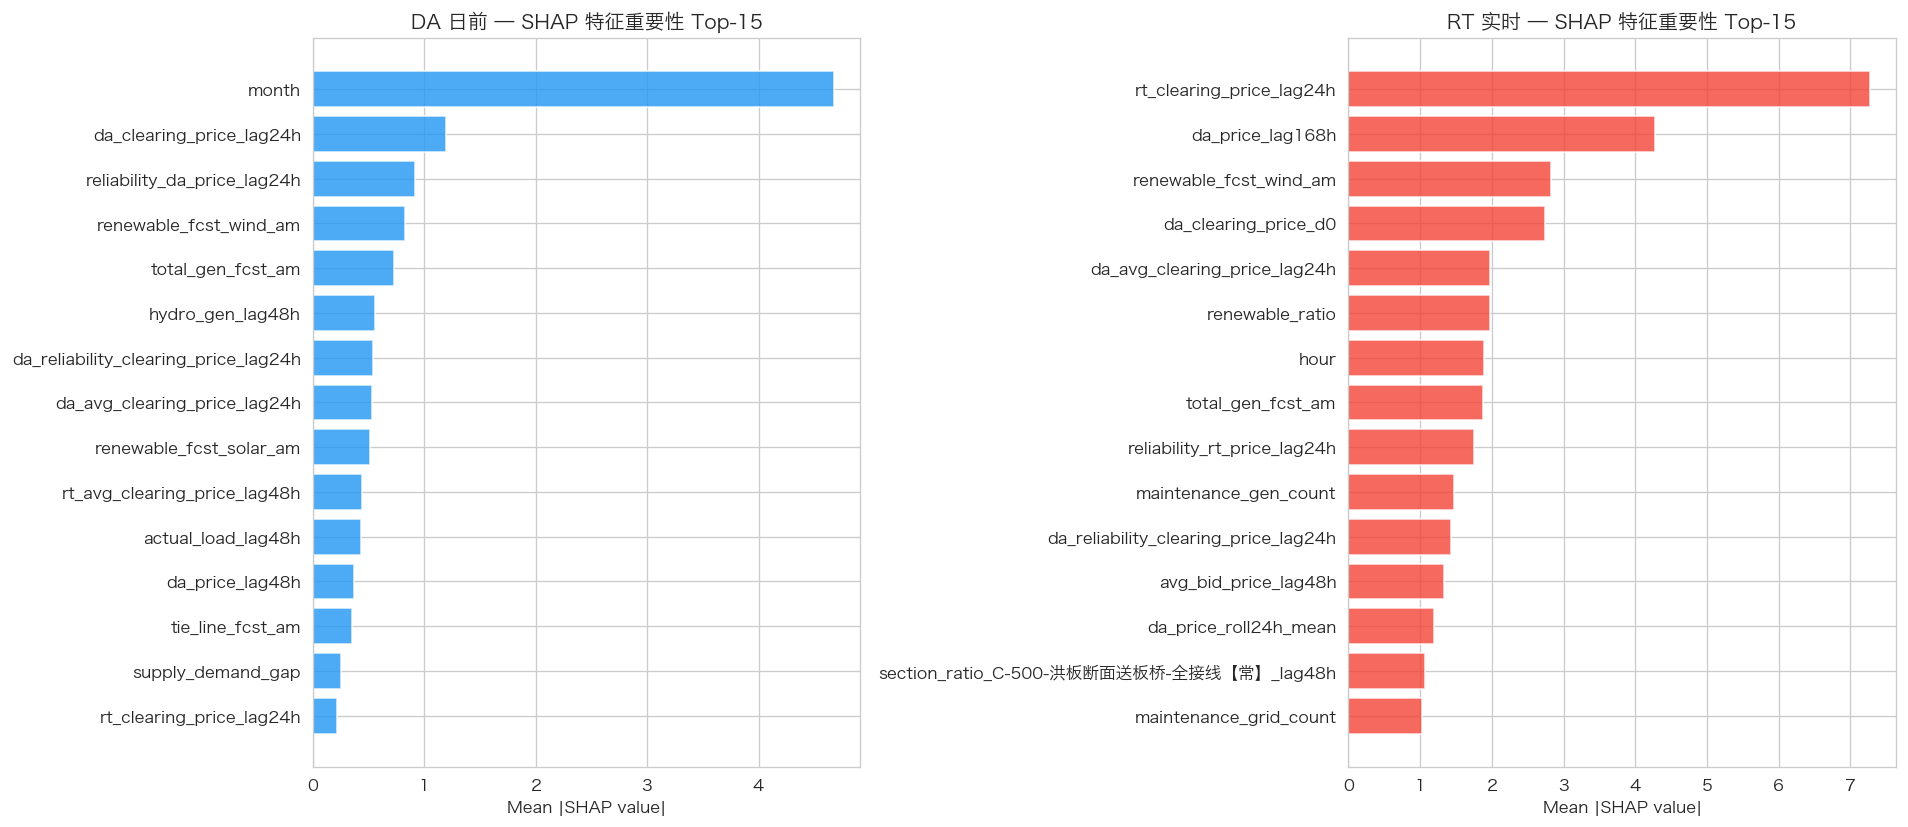

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, title) in zip(axes, [("da", "DA 日前"), ("rt", "RT 实时")]):
    sr = shap_results[name]
    mean_abs_shap = np.abs(sr["shap_values"]).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": sr["feature_cols"],
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=True).tail(15)

    ax.barh(importance_df["feature"], importance_df["mean_abs_shap"],
            color="#2196F3" if name == "da" else "#F44336", alpha=0.8)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"{title} — SHAP 特征重要性 Top-15", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_shap_importance.png", bbox_inches="tight")
plt.show()

### 6.3 SHAP Beeswarm 图

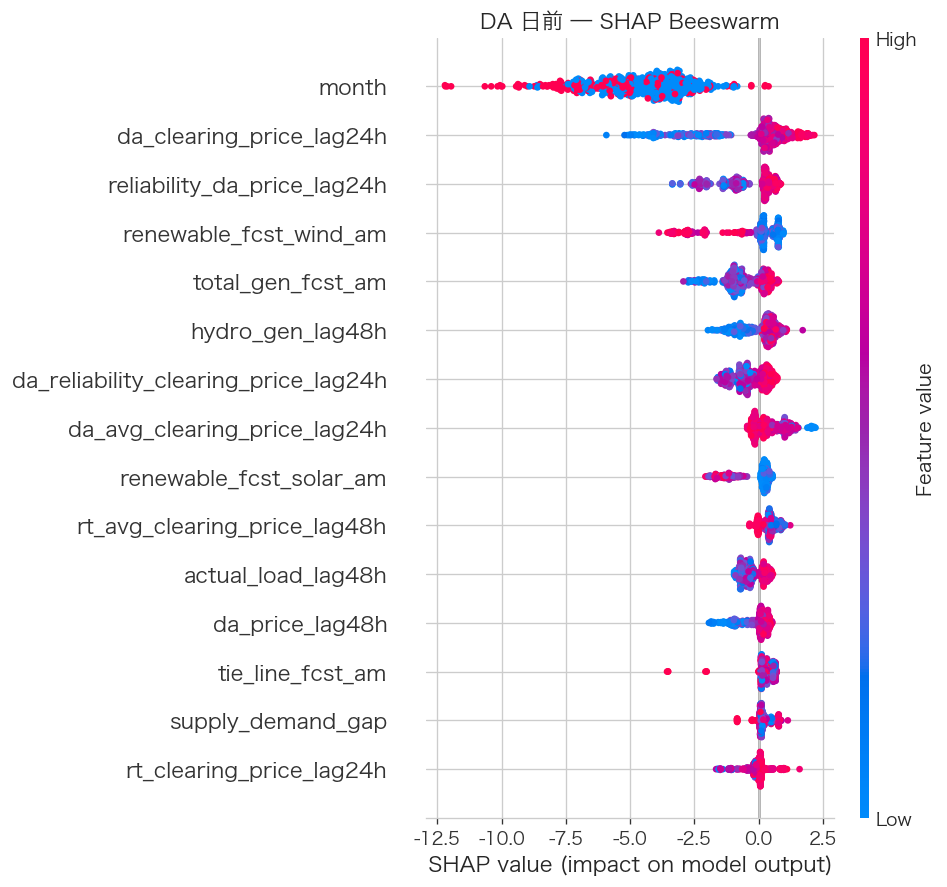

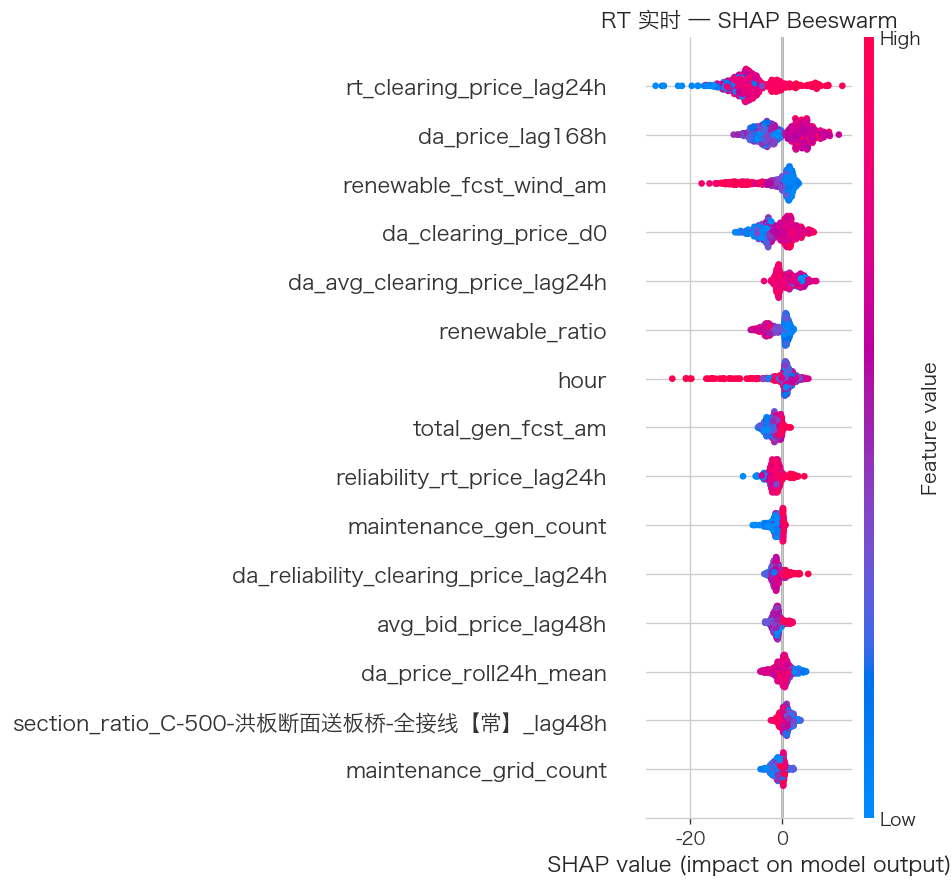

In [20]:
for name, title in [("da", "DA 日前"), ("rt", "RT 实时")]:
    sr = shap_results[name]
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(sr["shap_values"], sr["X_test"], max_display=15, show=False)
    plt.title(f"{title} — SHAP Beeswarm", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/eval_shap_beeswarm_{name}.png", bbox_inches="tight")
    plt.show()

### 6.4 SHAP Dependence Plot — Top-4 特征

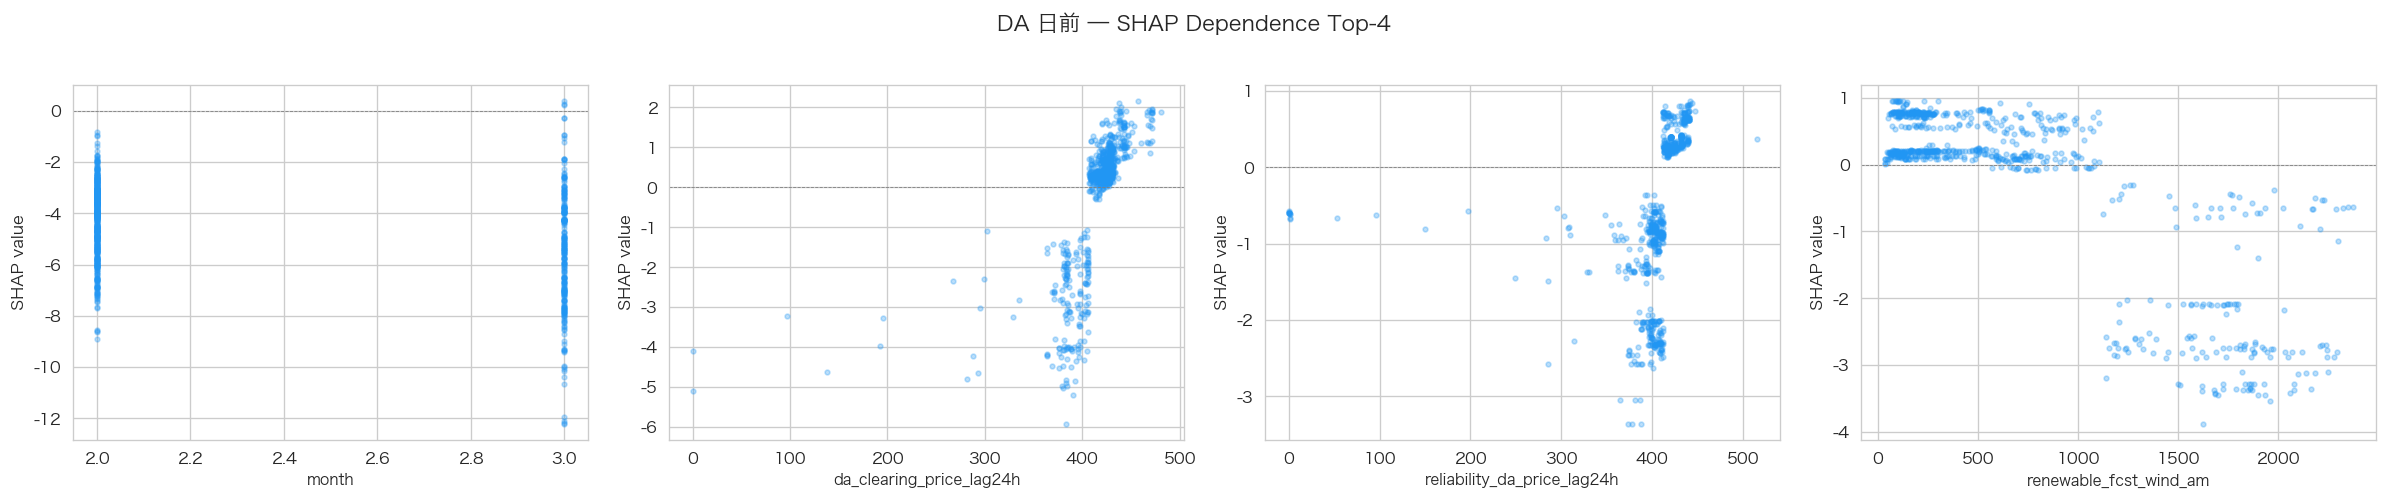

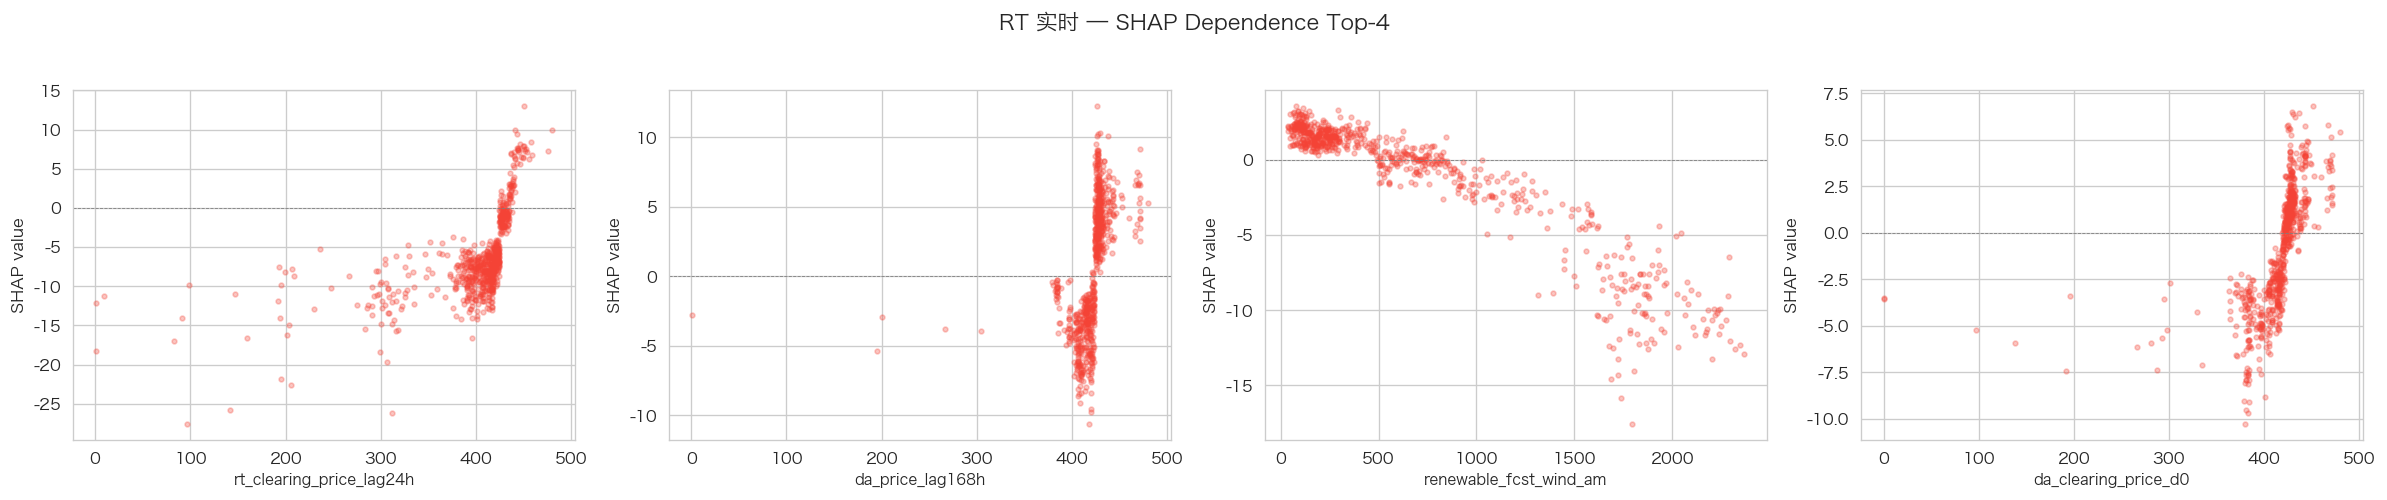

In [21]:
for name, title in [("da", "DA 日前"), ("rt", "RT 实时")]:
    sr = shap_results[name]
    mean_abs_shap = np.abs(sr["shap_values"]).mean(axis=0)
    top4_idx = np.argsort(mean_abs_shap)[-4:][::-1]
    top4_features = [sr["feature_cols"][i] for i in top4_idx]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, feat in zip(axes, top4_features):
        feat_idx = sr["feature_cols"].index(feat)
        ax.scatter(sr["X_test"][feat], sr["shap_values"][:, feat_idx],
                   alpha=0.3, s=8, c="#2196F3" if name == "da" else "#F44336")
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("SHAP value")
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    fig.suptitle(f"{title} — SHAP Dependence Top-4", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/eval_shap_dependence_{name}.png", bbox_inches="tight")
    plt.show()

## 7. 误差与特征关联分析

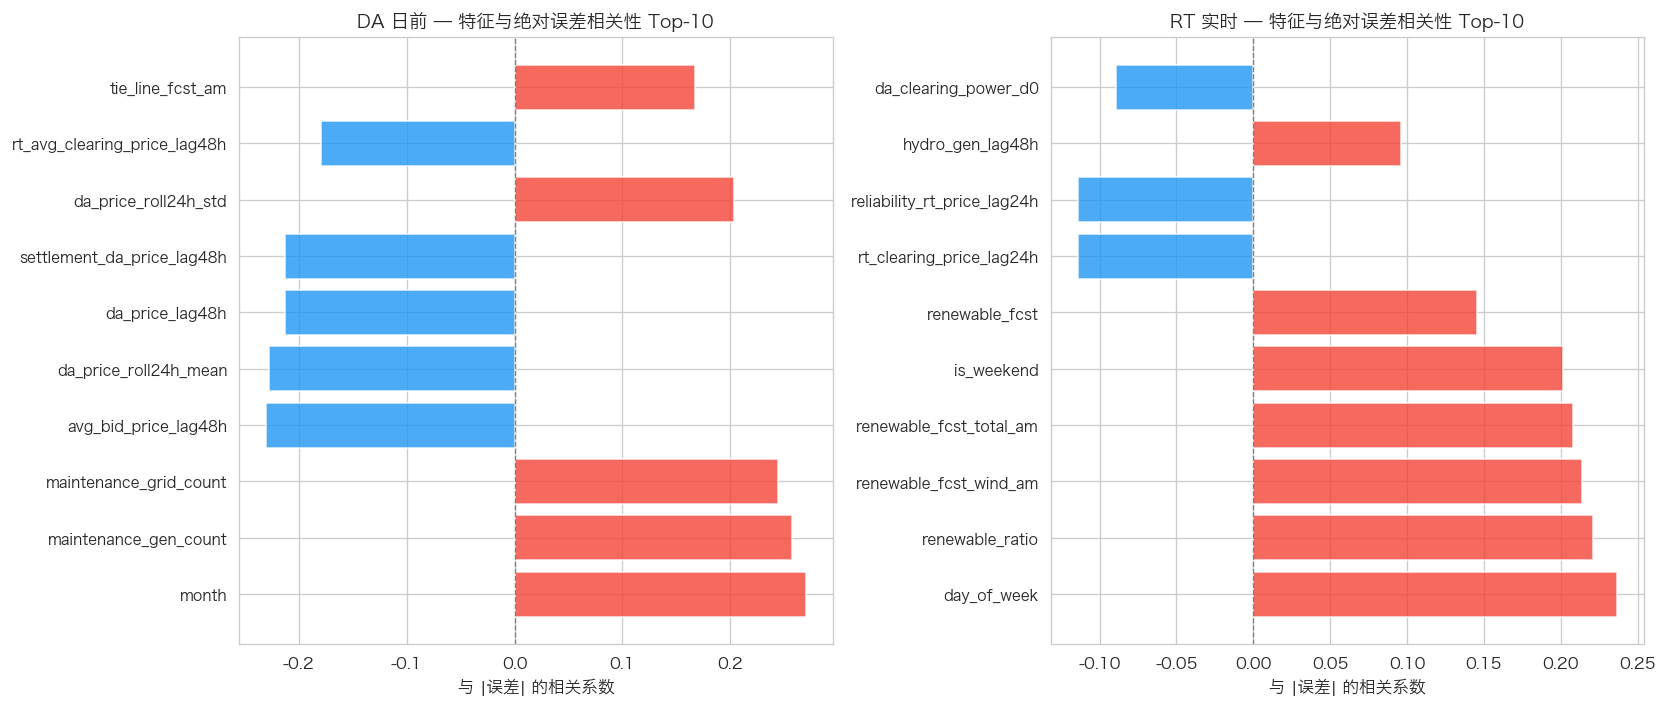

In [22]:
da_test_feat = da_feat.loc[TEST_START:].copy()
da_test_feat["abs_error"] = np.abs(da_res["residual_lgb"].values)
rt_test_feat = rt_feat.loc[TEST_START:].copy()
rt_test_feat["abs_error"] = np.abs(rt_res["residual_lgb"].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feat_df, title in zip(axes, [da_test_feat, rt_test_feat], ["DA 日前", "RT 实时"]):
    numeric_cols = [c for c in feat_df.columns if c not in ["abs_error", TARGET_DA, TARGET_RT] and feat_df[c].dtype != "object"]
    corr_with_error = feat_df[numeric_cols].corrwith(feat_df["abs_error"]).dropna().sort_values(key=abs, ascending=False).head(10)
    colors = ["#F44336" if v > 0 else "#2196F3" for v in corr_with_error.values]
    ax.barh(range(len(corr_with_error)), corr_with_error.values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(corr_with_error)))
    ax.set_yticklabels(corr_with_error.index, fontsize=9)
    ax.set_xlabel("与 |误差| 的相关系数")
    ax.set_title(f"{title} — 特征与绝对误差相关性 Top-10", fontsize=11, fontweight="bold")
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_error_feature_corr.png", bbox_inches="tight")
plt.show()

## 8. LightGBM Gain 特征重要性 vs SHAP 对比

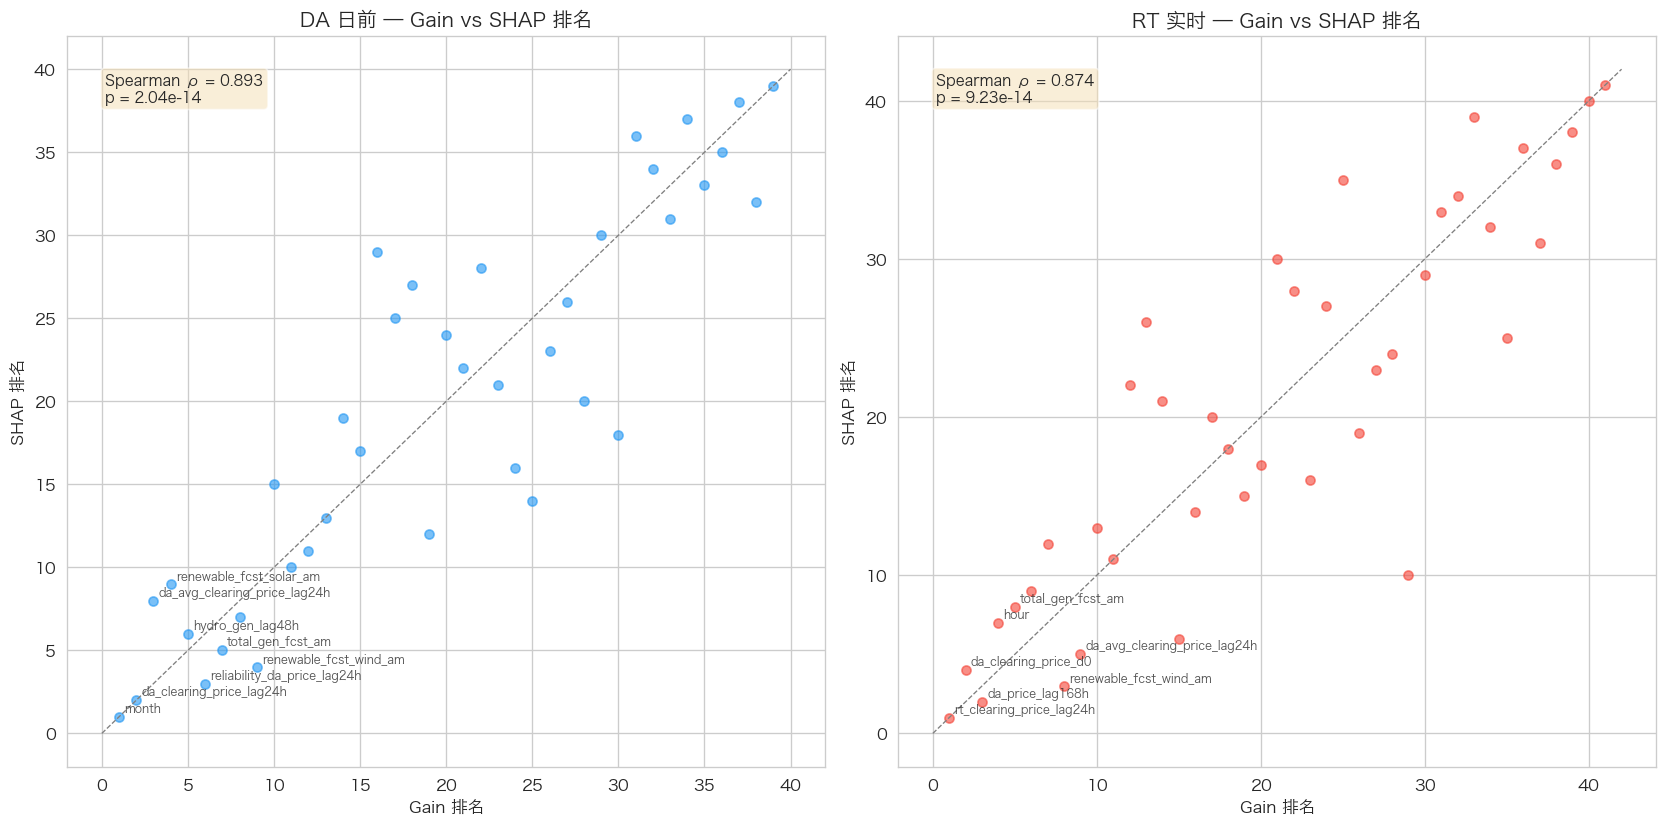

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (name, title) in zip(axes, [("da", "DA 日前"), ("rt", "RT 实时")]):
    sr = shap_results[name]
    model = sr["model"]

    gain_imp = pd.Series(model.feature_importance(importance_type="gain"), index=sr["feature_cols"])
    gain_rank = gain_imp.rank(ascending=False)

    shap_imp = pd.Series(np.abs(sr["shap_values"]).mean(axis=0), index=sr["feature_cols"])
    shap_rank = shap_imp.rank(ascending=False)

    rank_df = pd.DataFrame({"Gain Rank": gain_rank, "SHAP Rank": shap_rank})

    ax.scatter(rank_df["Gain Rank"], rank_df["SHAP Rank"], alpha=0.6, s=30,
              color="#2196F3" if name == "da" else "#F44336")
    max_rank = len(sr["feature_cols"]) + 1
    ax.plot([0, max_rank], [0, max_rank], "--", color="gray", linewidth=0.8)
    ax.set_xlabel("Gain 排名")
    ax.set_ylabel("SHAP 排名")
    ax.set_title(f"{title} — Gain vs SHAP 排名", fontsize=12, fontweight="bold")

    for feat in sr["feature_cols"]:
        if gain_rank[feat] <= 5 or shap_rank[feat] <= 5:
            ax.annotate(feat, (gain_rank[feat], shap_rank[feat]),
                        fontsize=7, alpha=0.8, ha="left",
                        xytext=(3, 3), textcoords="offset points")

    from scipy.stats import spearmanr
    rho, pval = spearmanr(rank_df["Gain Rank"], rank_df["SHAP Rank"])
    ax.text(0.05, 0.95, f"Spearman ρ = {rho:.3f}\np = {pval:.2e}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_gain_vs_shap.png", bbox_inches="tight")
plt.show()

## 9. 迭代方向建议

In [24]:
print("=" * 70)
print("模型评估总结与迭代建议")
print("=" * 70)

print("\n【1. 当前基线表现】")
for _, row in overall.iterrows():
    print(f"  {row['label']}: MAE={row['MAE']:.2f}, RMSE={row['RMSE']:.2f}, MAPE={row['MAPE(%)']:.2f}%")

print("\n【2. 残差分析发现】")
for name, res in [("DA", da_res), ("RT", rt_res)]:
    r = res["residual_lgb"]
    print(f"  {name}: 均值偏差={r.mean():.2f} (" + ("偏低估" if r.mean() > 0 else "偏高估") + ")")
    print(f"        极端残差: [{r.min():.1f}, {r.max():.1f}]")
    pct_large = (r.abs() > r.abs().quantile(0.95)).sum()
    print(f"        >P95 大误差点: {pct_large} 个 ({pct_large/len(r)*100:.1f}%)")

print("\n【3. 分时段表现差异】")
for name in ["da", "rt"]:
    sub = period_metrics[(period_metrics["model"] == name) & (period_metrics["method"] == "lgb")]
    worst = sub.loc[sub["MAE"].idxmax()]
    best = sub.loc[sub["MAE"].idxmin()]
    print(f"  {name.upper()}: 最差时段={worst['时段']}(MAE={worst['MAE']:.2f}), "
          f"最优时段={best['时段']}(MAE={best['MAE']:.2f})")

print("\n【4. SHAP 分析要点】")
for name in ["da", "rt"]:
    sr = shap_results[name]
    mean_abs_shap = np.abs(sr["shap_values"]).mean(axis=0)
    top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
    top5_feat = [sr["feature_cols"][i] for i in top5_idx]
    print(f"  {name.upper()} Top-5: {', '.join(top5_feat)}")

print("\n【5. 迭代方向建议】")
suggestions = [
    ("增加滞后特征", "当前仅用 lag24h/48h/168h，可尝试 lag72h、同时段多周均值等"),
    ("时段差异化建模", "峰/谷/平时段表现差异大，可考虑分时段训练独立模型"),
    ("极端值处理", "RT 的 MAPE 极高可能受极低价/零价影响，考虑对目标做截断或对数变换"),
    ("滚动窗口训练", "当前固定 100 天训练，可尝试滚动窗口(如最近 60-90 天)适应市场结构变化"),
    ("集成方法", "尝试 XGBoost、CatBoost 与 LightGBM 集成，或加入线性模型做 stacking"),
    ("残差自相关利用", "残差 ACF 若显著，可用 ARMA 对残差做二次修正"),
    ("外部信息引入", "天气数据(温度、光照)、节假日日历、特殊事件标记等"),
    ("超参数调优", "当前超参数为手动设定，可用 Optuna 做贝叶斯搜索"),
]
for i, (title, desc) in enumerate(suggestions, 1):
    print(f"  {i}. {title}: {desc}")

模型评估总结与迭代建议

【1. 当前基线表现】
  DA - LGB: MAE=17.54, RMSE=36.25, MAPE=4.80%
  DA - NAIVE: MAE=23.74, RMSE=47.31, MAPE=6.37%
  RT - LGB: MAE=29.50, RMSE=57.37, MAPE=124.80%
  RT - NAIVE: MAE=41.14, RMSE=76.24, MAPE=115.68%

【2. 残差分析发现】
  DA: 均值偏差=-2.85 (偏高估)
        极端残差: [-404.7, 69.4]
        >P95 大误差点: 35 个 (4.9%)
  RT: 均值偏差=-13.71 (偏高估)
        极端残差: [-399.0, 62.9]
        >P95 大误差点: 36 个 (5.0%)

【3. 分时段表现差异】
  DA: 最差时段=谷(MAE=19.55), 最优时段=平(MAE=15.21)
  RT: 最差时段=峰(MAE=39.69), 最优时段=平(MAE=22.44)

【4. SHAP 分析要点】
  DA Top-5: month, da_clearing_price_lag24h, reliability_da_price_lag24h, renewable_fcst_wind_am, total_gen_fcst_am
  RT Top-5: rt_clearing_price_lag24h, da_price_lag168h, renewable_fcst_wind_am, da_clearing_price_d0, da_avg_clearing_price_lag24h

【5. 迭代方向建议】
  1. 增加滞后特征: 当前仅用 lag24h/48h/168h，可尝试 lag72h、同时段多周均值等
  2. 时段差异化建模: 峰/谷/平时段表现差异大，可考虑分时段训练独立模型
  3. 极端值处理: RT 的 MAPE 极高可能受极低价/零价影响，考虑对目标做截断或对数变换
  4. 滚动窗口训练: 当前固定 100 天训练，可尝试滚动窗口(如最近 60-90 天)适应市场结构变化
  5. 集成方法: 尝试 XGBoost、CatBoo

---

**本 notebook 主要发现：**

- LightGBM 在 DA/RT 两个任务上均显著优于 Naive baseline
- DA 模型表现稳定（MAE~17.5, MAPE~4.8%），RT 模型波动较大（MAPE 受极端值干扰严重）
- 残差存在一定的时序相关性，后续可通过残差修正进一步提升
- 价格滞后特征（lag24h）和负荷预测是最重要的驱动因素
- 峰时段预测误差显著高于谷/平时段，建议分时段建模或加入更多峰时段相关特征